# Module 3
## KMeans Euclidean

In [2]:
import pandas as pd
df=pd.read_csv('input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_3_0.01', index_col=0, sep='\t')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (172, 16)


,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16
snR189,129.158,286.101,164.031,385.956,347.524,494.922,234.330,2016.780,414.220,151.881,117.165,482.445,98.814,120.611,640.747,464.239
YPR153W,404.451,335.310,396.504,328.653,213.831,341.814,695.169,546.596,327.689,333.757,360.458,331.303,238.858,304.799,281.608,255.041
YBR082C,352.001,557.620,447.042,535.494,619.934,378.374,510.905,453.038,763.542,1046.110,476.070,585.696,519.019,705.226,444.501,429.405
YPR052C,415.154,503.849,486.149,347.475,237.983,387.886,154.772,732.473,535.492,819.398,392.719,438.735,846.152,640.970,347.617,743.640
YPR182W,4537.110,5555.410,3851.080,3644.980,4196.090,3769.200,4467.410,4082.240,3246.520,3512.190,2730.090,2597.470,4744.510,4556.230,3438.460,4261.370


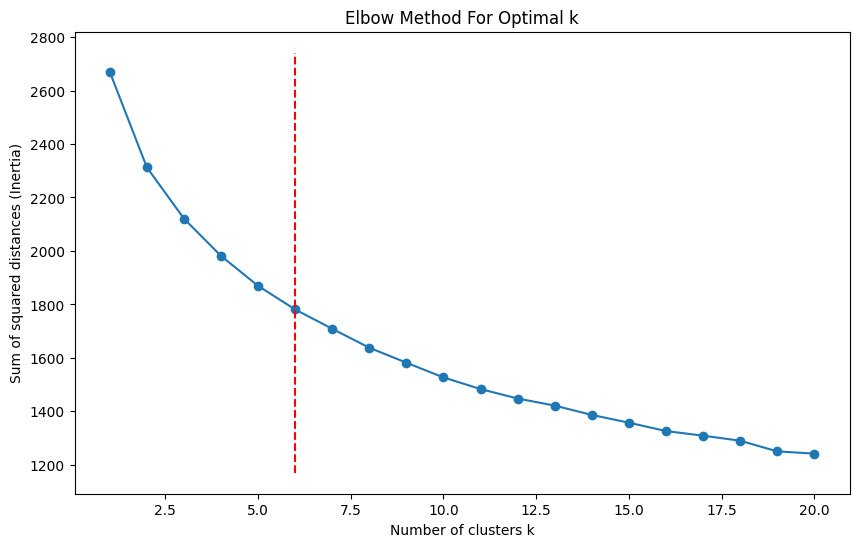

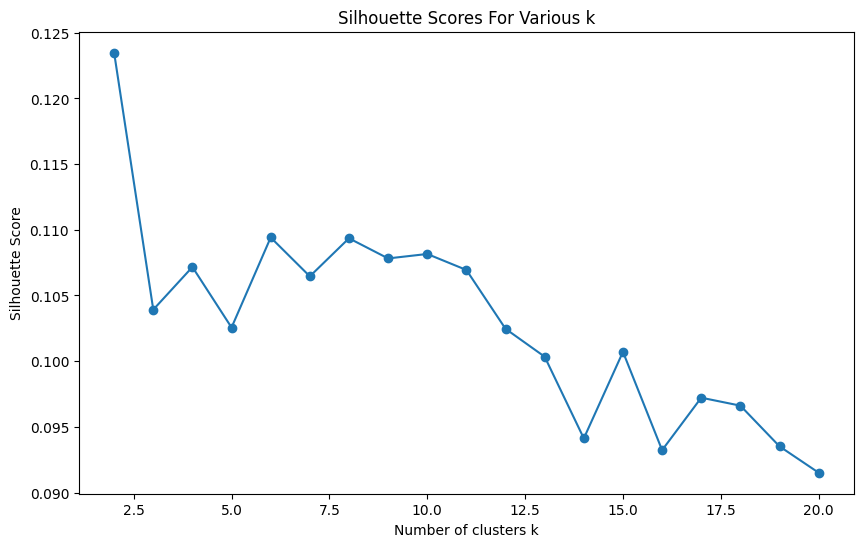

In [3]:
# scale the data rowwise
from sklearn.preprocessing import StandardScaler
# Apply StandardScaler row-wise
scaler = StandardScaler() # mean od 0 and std of 1
scaled_array = scaler.fit_transform(df.T).T  # Transpose to scale rows, then transpose back

# Create scaled DataFrame
scaled_df = pd.DataFrame(scaled_array, index=df.index, columns=df.columns)

from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the elbow method
sse = []
k_range = range(1, 21)  # Testing k from 1 to 20
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_) # Inertia: Sum of squared distances to closest cluster center   
# Plotting the elbow curve with knee locator
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.vlines(knee.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='r')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters k')
plt.ylabel('Sum of squared distances (Inertia)')
plt.show()

# silhuette score 
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 21): 
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)
# Plotting silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 21), silhouette_scores, marker='o')
plt.title('Silhouette Scores For Various k')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.show()

In [4]:
scaled_df.head()

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16
snR189,-0.629051,-0.276650,-0.550747,-0.052434,-0.138730,0.192239,-0.392897,3.609437,0.011030,-0.578029,-0.655981,0.164223,-0.697186,-0.648243,0.519676,0.123343
YPR153W,0.422062,-0.180109,0.352849,-0.238087,-1.238108,-0.123464,2.954017,1.660048,-0.246483,-0.193635,0.038913,-0.215007,-1.020140,-0.445839,-0.647817,-0.879197
YBR082C,-1.196902,0.036726,-0.626696,-0.096021,0.410584,-1.038675,-0.243544,-0.590722,1.272172,2.967463,-0.452540,0.205170,-0.194864,0.922301,-0.641941,-0.732511
YPR052C,-0.438618,0.009834,-0.079659,-0.780811,-1.334416,-0.576488,-1.755140,1.165784,0.169825,1.605287,-0.552052,-0.319390,1.740559,0.703134,-0.780093,1.222246
YPR182W,0.794062,2.169895,-0.132837,-0.411301,0.333308,-0.243466,0.699890,0.179484,-0.949663,-0.590714,-1.647415,-1.826599,1.074282,0.819896,-0.690331,0.421508


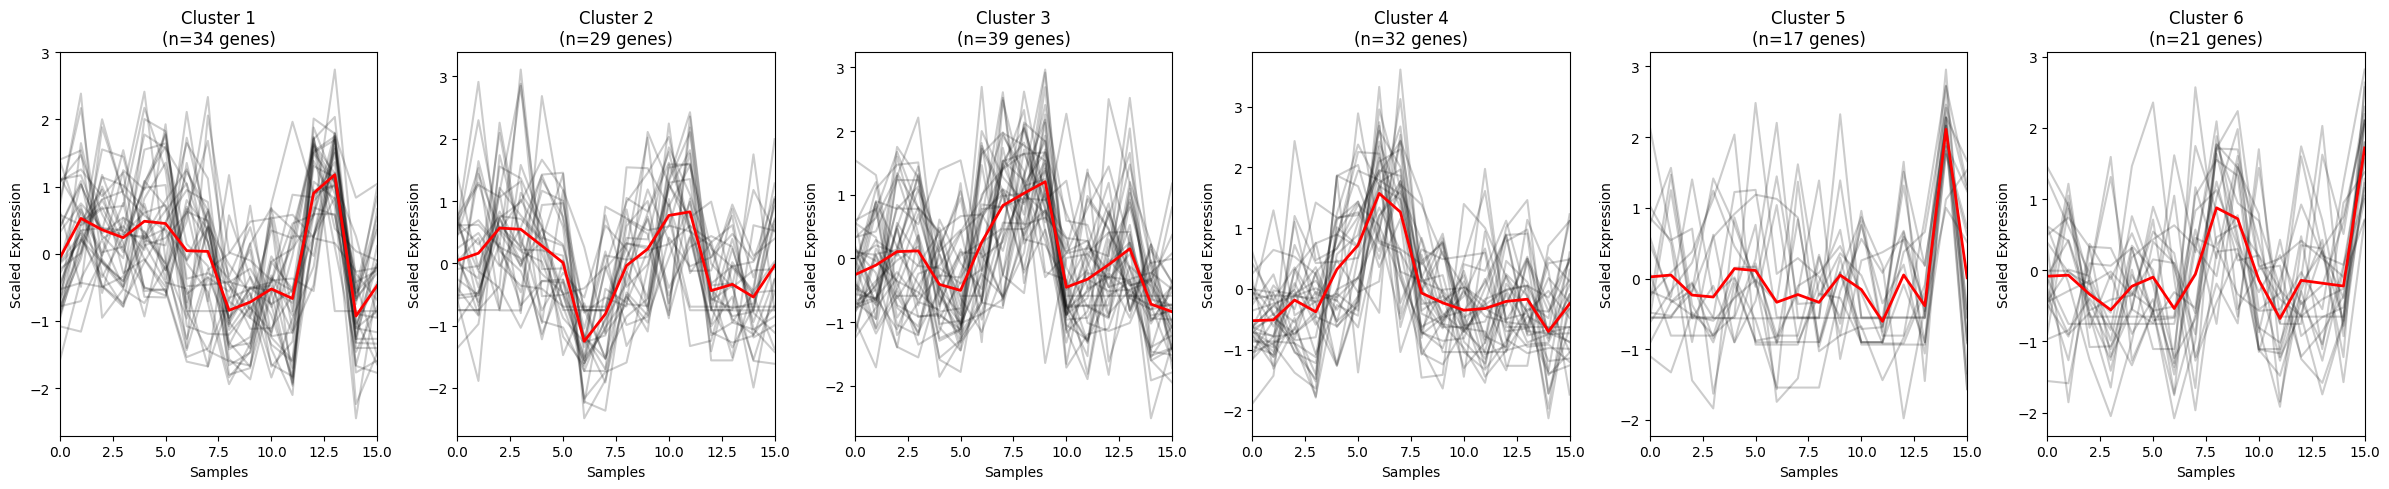

Silhouette Score for k=6: 0.1094


In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# -----------------------
# 1. KMeans clustering
# -----------------------
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(scaled_df)

# Add cluster labels to the DataFrame
scaled_df['cluster'] = labels

# -----------------------
# 2. Plot clusters side by side
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))  # width scales with number of clusters

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for index, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.values, color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()
# print sillhouette score
score = silhouette_score(scaled_df.drop(columns='cluster'), labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')


# Module 4
## KMeans Euclidean

Shape of dataset: (158, 16)


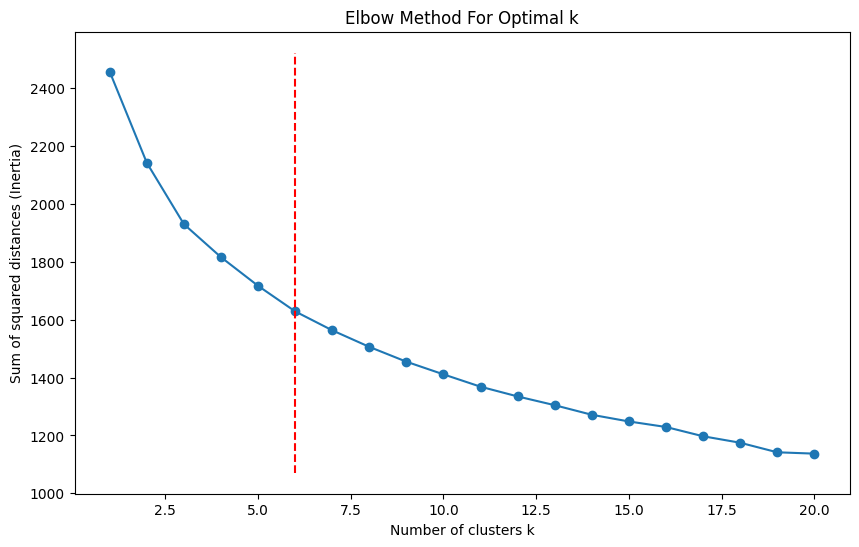

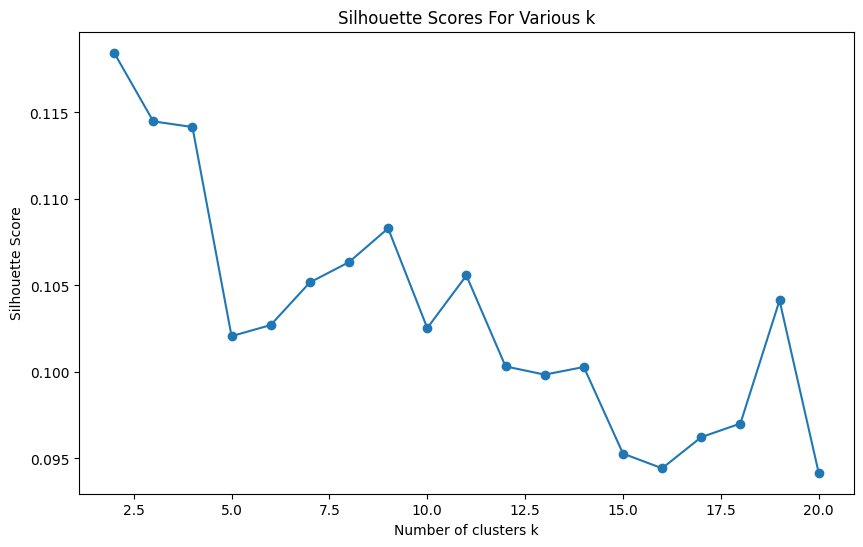

In [6]:
df=pd.read_csv('input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_4_0.01', index_col=0, sep='\t')
print("Shape of dataset:", df.shape)
# scale the data rowwise
from sklearn.preprocessing import StandardScaler
# Apply StandardScaler row-wise
scaler = StandardScaler() # mean od 0 and std of 1
scaled_array = scaler.fit_transform(df.T).T  # Transpose to scale rows, then transpose back

# Create scaled DataFrame
scaled_df = pd.DataFrame(scaled_array, index=df.index, columns=df.columns)

from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the elbow method
sse = []
k_range = range(1, 21)  # Testing k from 1 to 20
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_) # Inertia: Sum of squared distances to closest cluster center   
# Plotting the elbow curve with knee locator
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.vlines(knee.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='r')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters k')
plt.ylabel('Sum of squared distances (Inertia)')
plt.show()

# silhuette score 
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 21): 
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)
# Plotting silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 21), silhouette_scores, marker='o')
plt.title('Silhouette Scores For Various k')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.show()

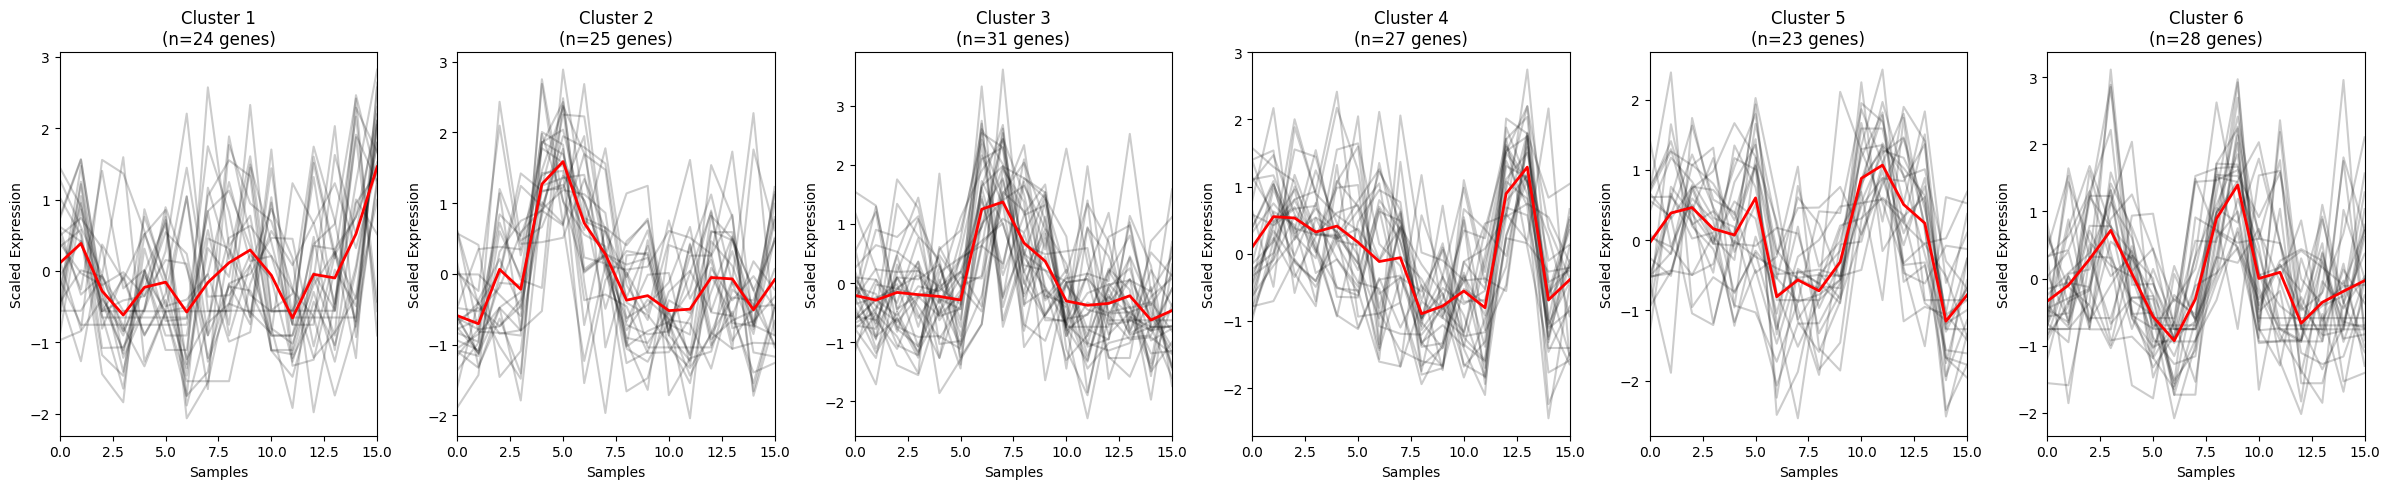

Silhouette Score for k=6: 0.1027


In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# -----------------------
# 1. KMeans clustering
# -----------------------
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(scaled_df)

# Add cluster labels to the DataFrame
scaled_df['cluster'] = labels

# -----------------------
# 2. Plot clusters side by side
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))  # width scales with number of clusters

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for index, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.values, color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()
# print sillhouette score
score = silhouette_score(scaled_df.drop(columns='cluster'), labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')


# Module 5
## Kmeans Euclidean

Shape of dataset: (136, 16)


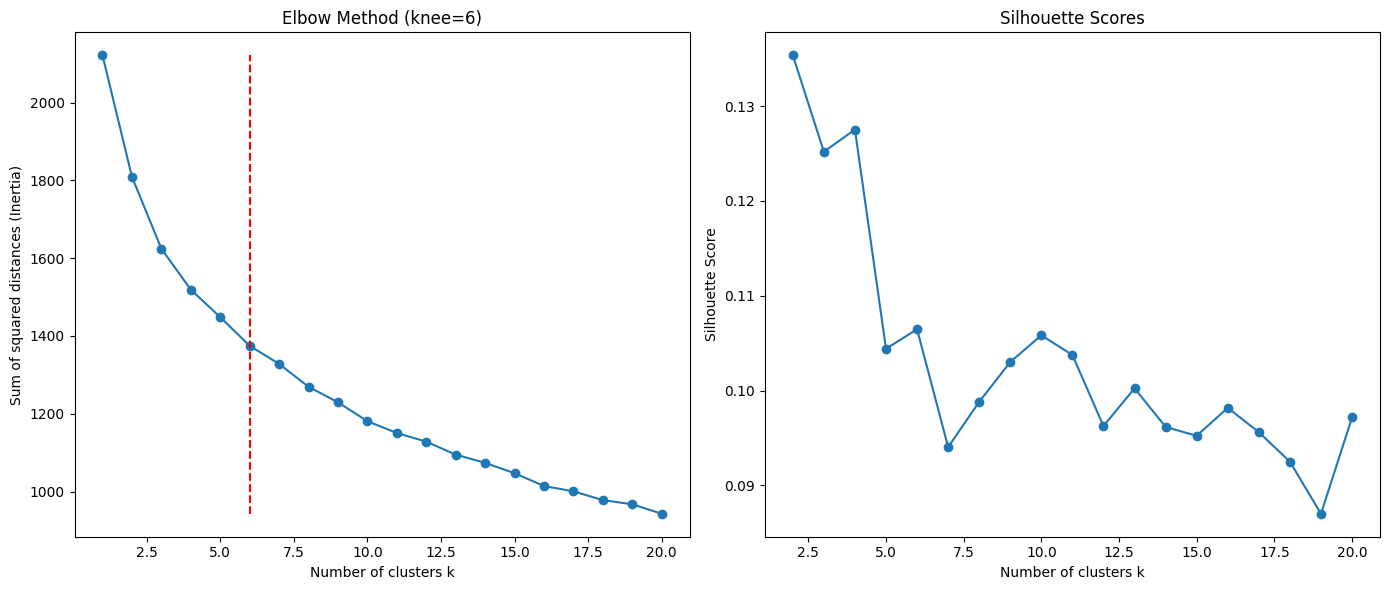

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_5_0.01',
    index_col=0, sep='\t'
)
print("Shape of dataset:", df.shape)

# -----------------------
# 2. Scale the data row-wise
# -----------------------
scaler = StandardScaler()  # mean 0, std 1
scaled_array = scaler.fit_transform(df.T).T  # scale rows
scaled_df = pd.DataFrame(scaled_array, index=df.index, columns=df.columns)

# -----------------------
# 3. Elbow method (Inertia)
# -----------------------
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')

# -----------------------
# 4. Silhouette scores
# -----------------------
silhouette_scores = []
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)

# -----------------------
# 5. Plot both side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method (knee={knee.knee})')
else:
    axes[0].set_title("Elbow Method (no clear knee)")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances (Inertia)')

# Silhouette plot
axes[1].plot(range(2, 21), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


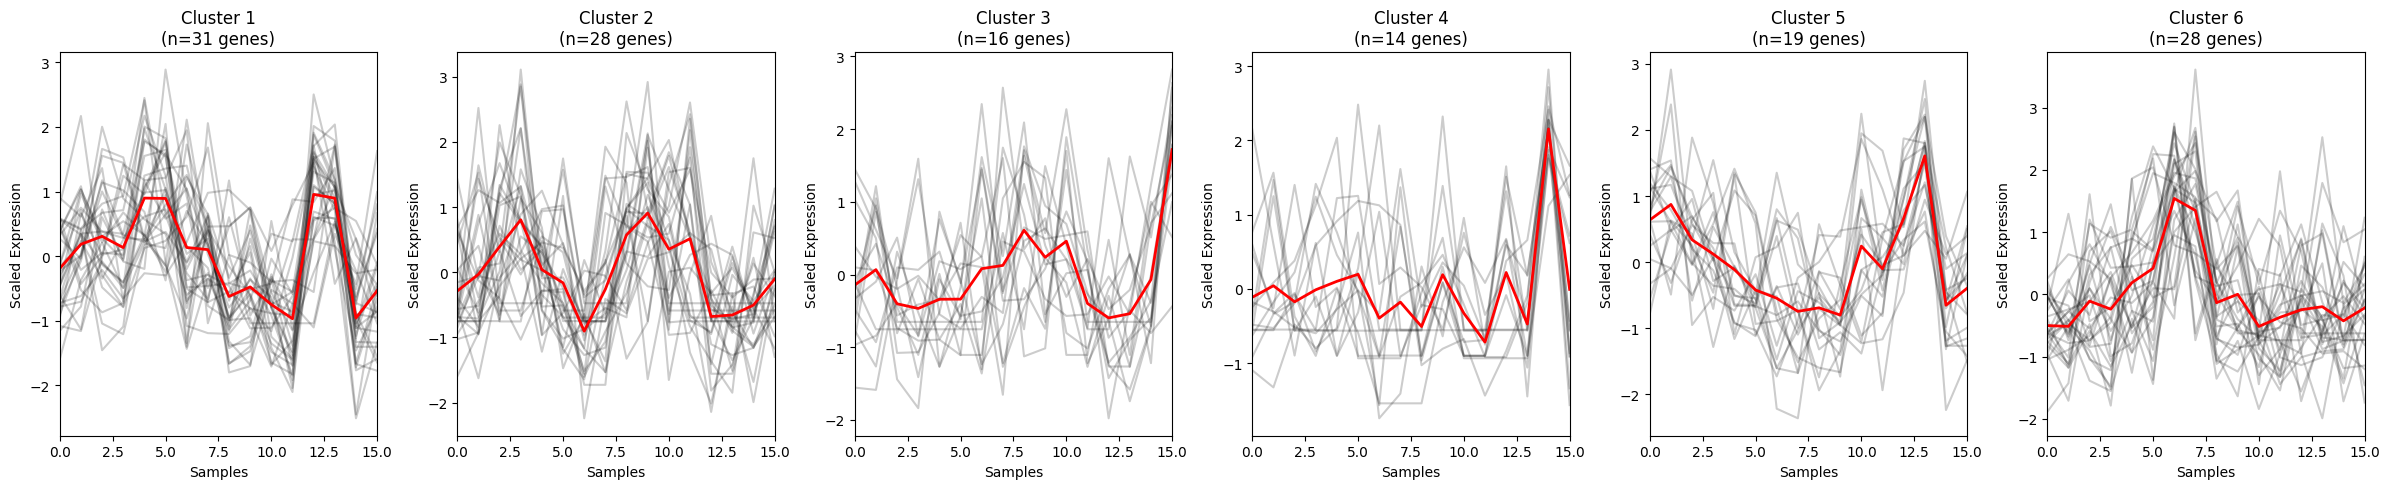

Silhouette Score for k=6: 0.1065


In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# -----------------------
# 1. KMeans clustering
# -----------------------
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(scaled_df)

# Add cluster labels to the DataFrame
scaled_df['cluster'] = labels

# -----------------------
# 2. Plot clusters side by side
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))  # width scales with number of clusters

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for index, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.values, color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()
# print sillhouette score
score = silhouette_score(scaled_df.drop(columns='cluster'), labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')


# Module 6 
## Kmeans Euclidean

Shape of dataset: (151, 16)


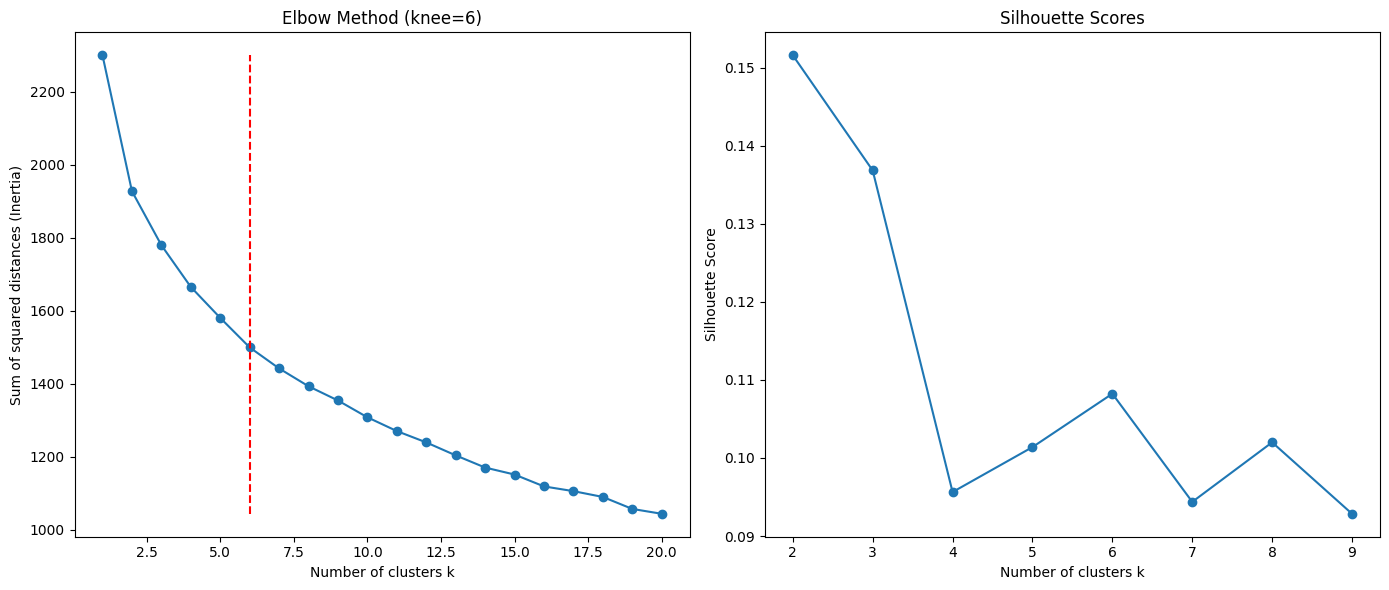

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_6_0.01',
    index_col=0, sep='\t'
)
print("Shape of dataset:", df.shape)

# -----------------------
# 2. Scale the data row-wise
# -----------------------
scaler = StandardScaler()  # mean 0, std 1
scaled_array = scaler.fit_transform(df.T).T  # scale rows
scaled_df = pd.DataFrame(scaled_array, index=df.index, columns=df.columns)

# -----------------------
# 3. Elbow method (Inertia)
# -----------------------
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')

# -----------------------
# 4. Silhouette scores
# -----------------------
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)

# -----------------------
# 5. Plot both side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method (knee={knee.knee})')
else:
    axes[0].set_title("Elbow Method (no clear knee)")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances (Inertia)')

# Silhouette plot
axes[1].plot(range(2, 10), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


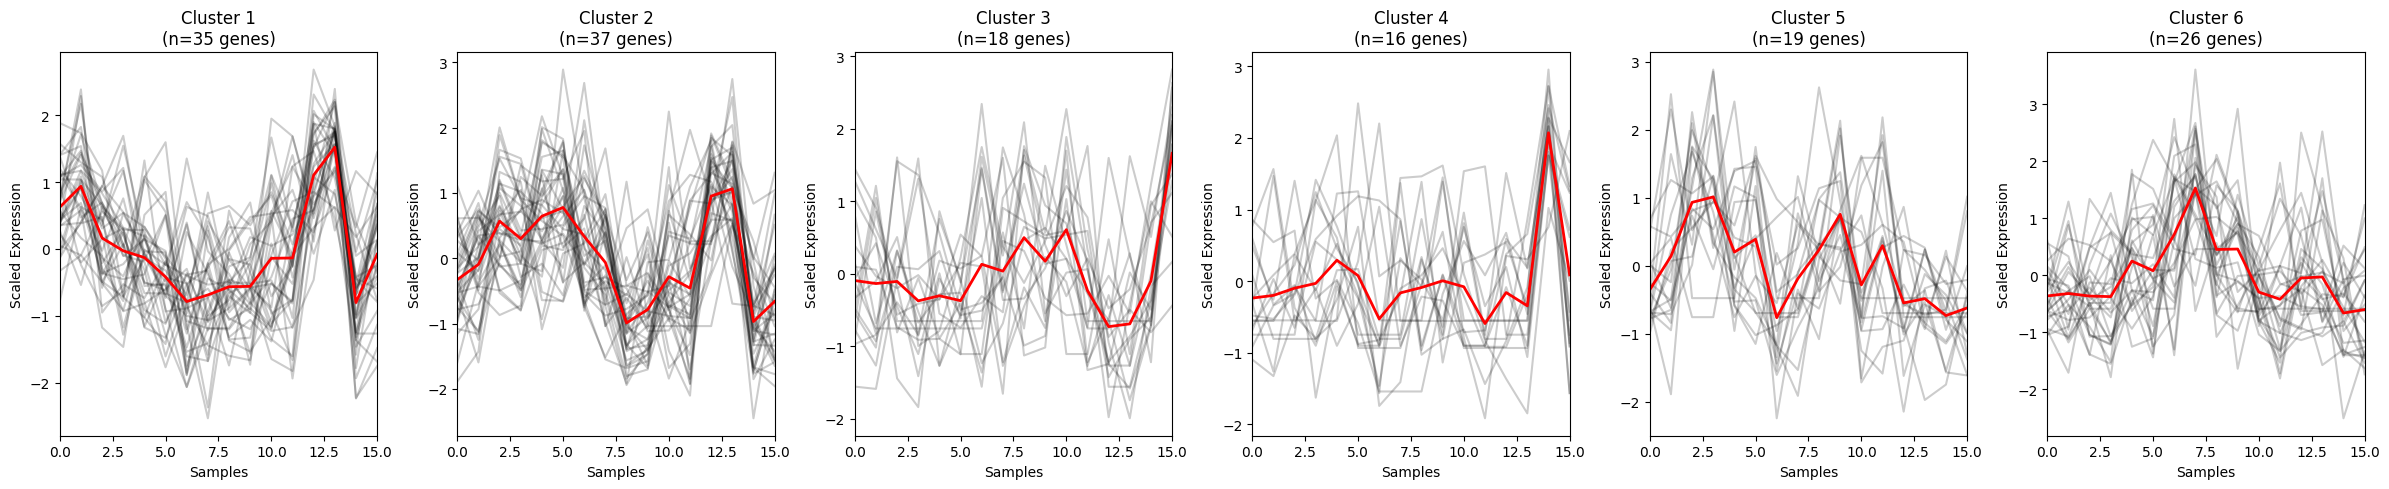

Silhouette Score for k=6: 0.1082


In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# -----------------------
# 1. KMeans clustering
# -----------------------
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(scaled_df)

# Add cluster labels to the DataFrame
scaled_df['cluster'] = labels

# -----------------------
# 2. Plot clusters side by side
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))  # width scales with number of clusters

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for index, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.values, color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()
# print sillhouette score
score = silhouette_score(scaled_df.drop(columns='cluster'), labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')


# Module 7
## Kmeans Euclidean

Shape of dataset: (91, 16)


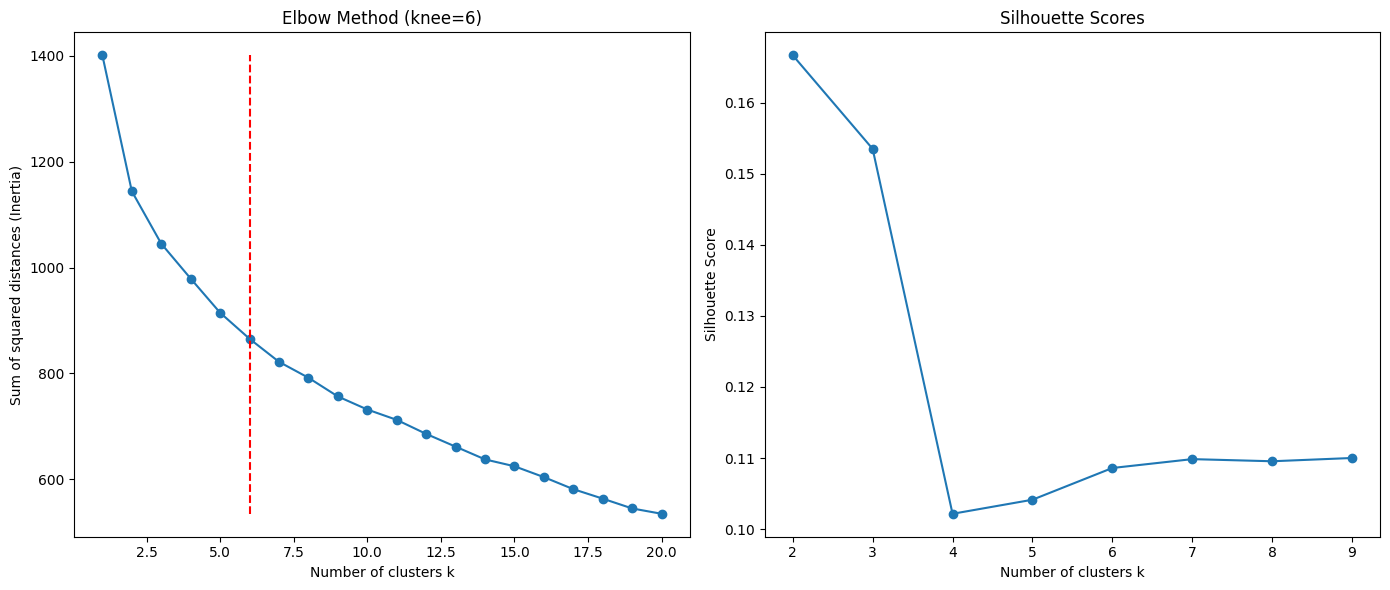

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_7_0.01',
    index_col=0, sep='\t'
)
print("Shape of dataset:", df.shape)

# -----------------------
# 2. Scale the data row-wise
# -----------------------
scaler = StandardScaler()  # mean 0, std 1
scaled_array = scaler.fit_transform(df.T).T  # scale rows
scaled_df = pd.DataFrame(scaled_array, index=df.index, columns=df.columns)

# -----------------------
# 3. Elbow method (Inertia)
# -----------------------
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')

# -----------------------
# 4. Silhouette scores
# -----------------------
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)

# -----------------------
# 5. Plot both side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method (knee={knee.knee})')
else:
    axes[0].set_title("Elbow Method (no clear knee)")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances (Inertia)')

# Silhouette plot
axes[1].plot(range(2, 10), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


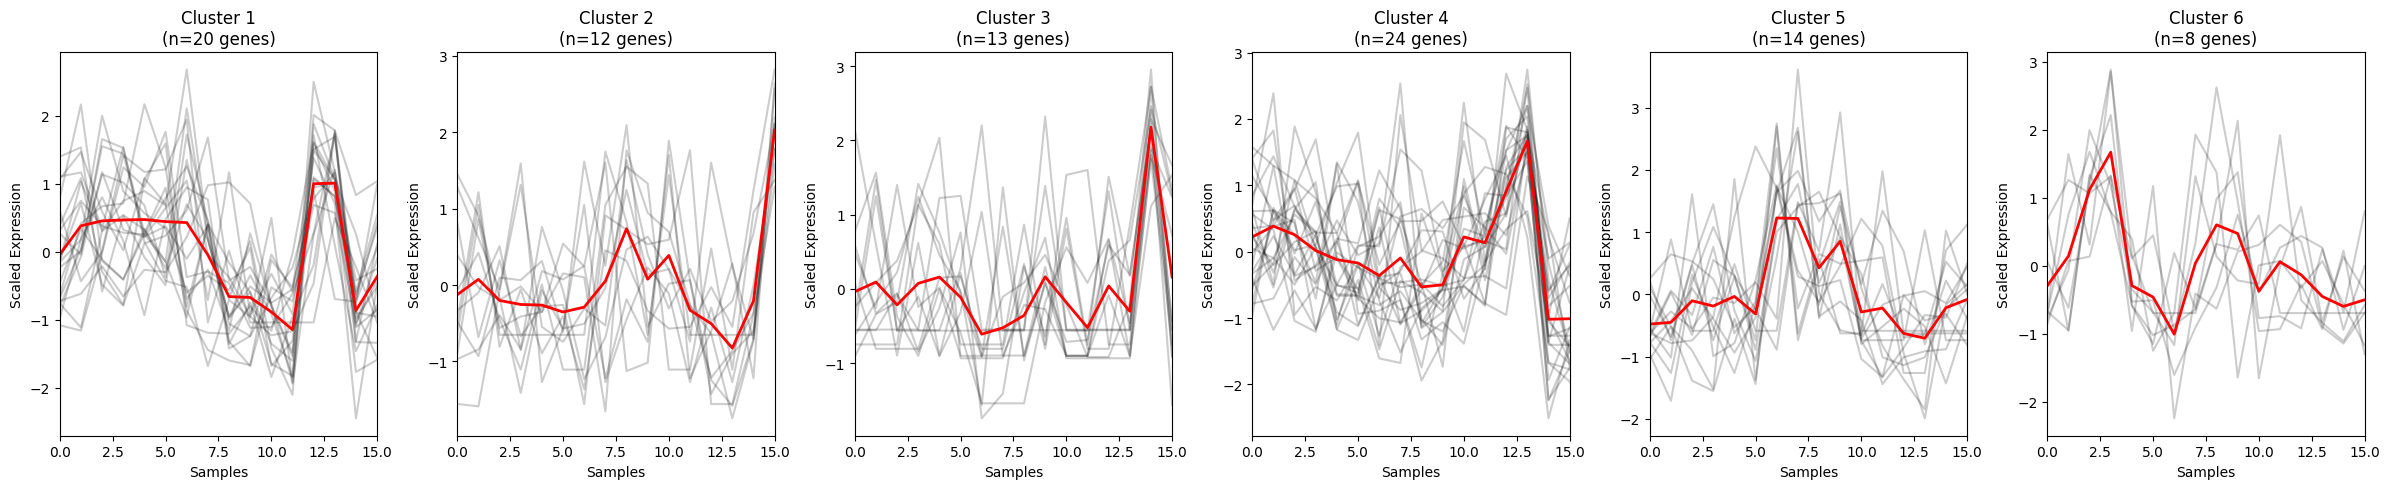

Silhouette Score for k=6: 0.1086


In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# -----------------------
# 1. KMeans clustering
# -----------------------
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(scaled_df)

# Add cluster labels to the DataFrame
scaled_df['cluster'] = labels

# -----------------------
# 2. Plot clusters side by side
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))  # width scales with number of clusters

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for index, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.values, color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()
# print sillhouette score
score = silhouette_score(scaled_df.drop(columns='cluster'), labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')


# DTW 
## Module 3

/Users/irmaskaljo/codedev/thesis/.venv/lib/python3.13/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Shape of dataset: (172, 16)
Number of time points: 16
Suggested k (elbow method): 3


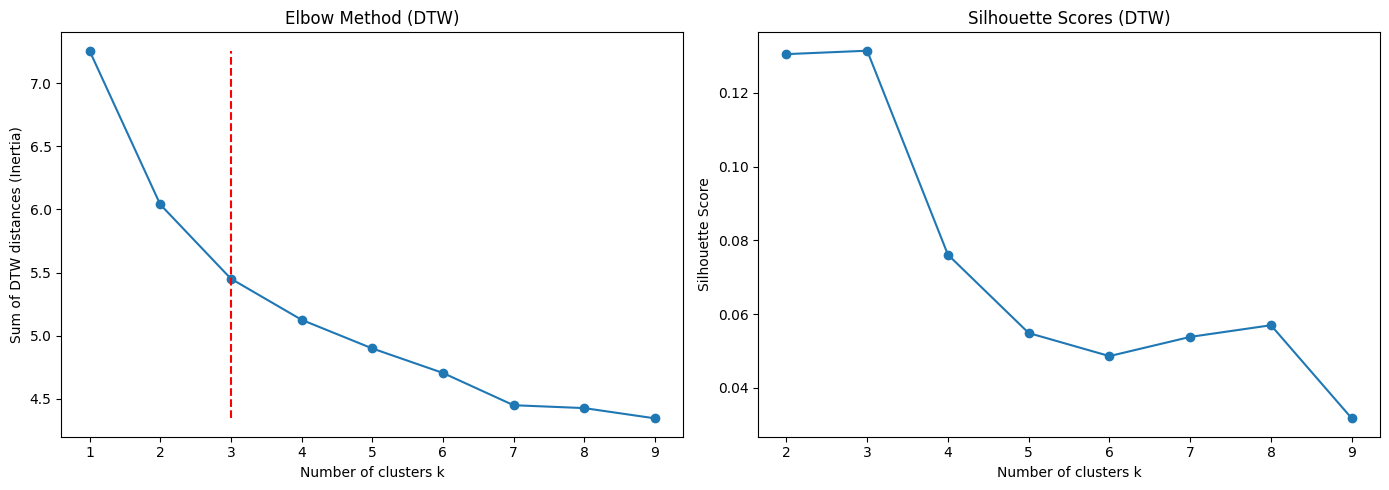

In [14]:
# 1. Import libraries
# -----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


df=pd.read_csv('input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_3_0.01', index_col=0, sep='\t')
print("Shape of dataset:", df.shape)

# -----------------------
# 3. Scale row-wise
# -----------------------
# tslearn expects 3D array: (n_samples, n_timestamps, n_features)
X = df.values[:, :, np.newaxis]  # add 3rd dimension
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# Convert X_scaled to 2D for DataFrame/plotting: (n_genes, n_samples)
X_scaled_2d = X_scaled[:, :, 0]
scaled_df = pd.DataFrame(X_scaled_2d, index=df.index, columns=df.columns)

sz = X_scaled.shape[1]  # number of time points (samples)
print("Number of time points:", sz)

sse = []
sil_scores = []
k_range = range(1, 10)

for k in k_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=42, n_init=2, max_iter_barycenter=10)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    
    if k > 1:
        dist_matrix = cdist_dtw(X_scaled)
        score = silhouette_score(dist_matrix, labels, metric='precomputed')
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

# -----------------------
# 4. Detect elbow
# -----------------------
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
print("Suggested k (elbow method):", knee.knee)

# -----------------------
# 5. Plot elbow and silhouette side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
axes[0].set_title("Elbow Method (DTW)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Sum of DTW distances (Inertia)")

# Silhouette plot
axes[1].plot(k_range[1:], sil_scores[1:], marker='o')
axes[1].set_title("Silhouette Scores (DTW)")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(range(2, 10))

plt.tight_layout()
plt.show()

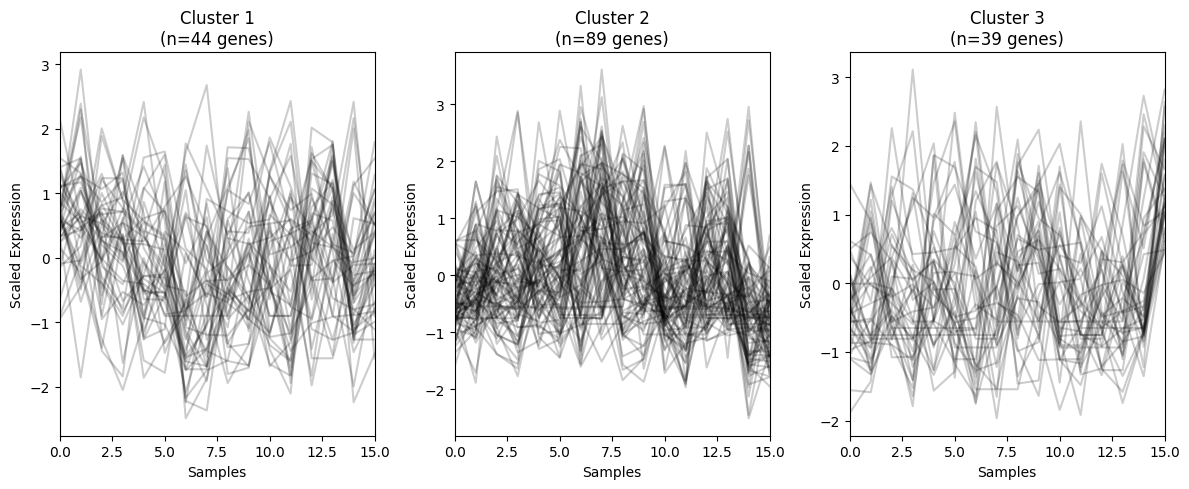

Silhouette Score (DTW) for k=3: 0.1314


In [15]:
# DTW Clustering
# -----------------------
n_clusters = 3  # choose your k
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42, n_init=2, max_iter_barycenter=10)
labels = km.fit_predict(X_scaled)

scaled_df['cluster'] = labels

# -----------------------
# 4. Plot clusters (scaled data)
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for _, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot DTW barycenter in red
    #plt.plot(km.cluster_centers_[cluster].ravel(), color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()

# -----------------------
# 5. Silhouette Score (Euclidean on scaled data)
# -----------------------
dtw_dist_matrix = cdist_dtw(X_scaled)  # shape: (n_genes, n_genes)

#  Compute silhouette score with precomputed distances
score = silhouette_score(dtw_dist_matrix, labels, metric='precomputed')

print(f"Silhouette Score (DTW) for k={len(np.unique(labels))}: {score:.4f}")


# Module 4, DTW

Shape of dataset: (158, 16)
Number of time points: 16
Suggested k (elbow method): 4


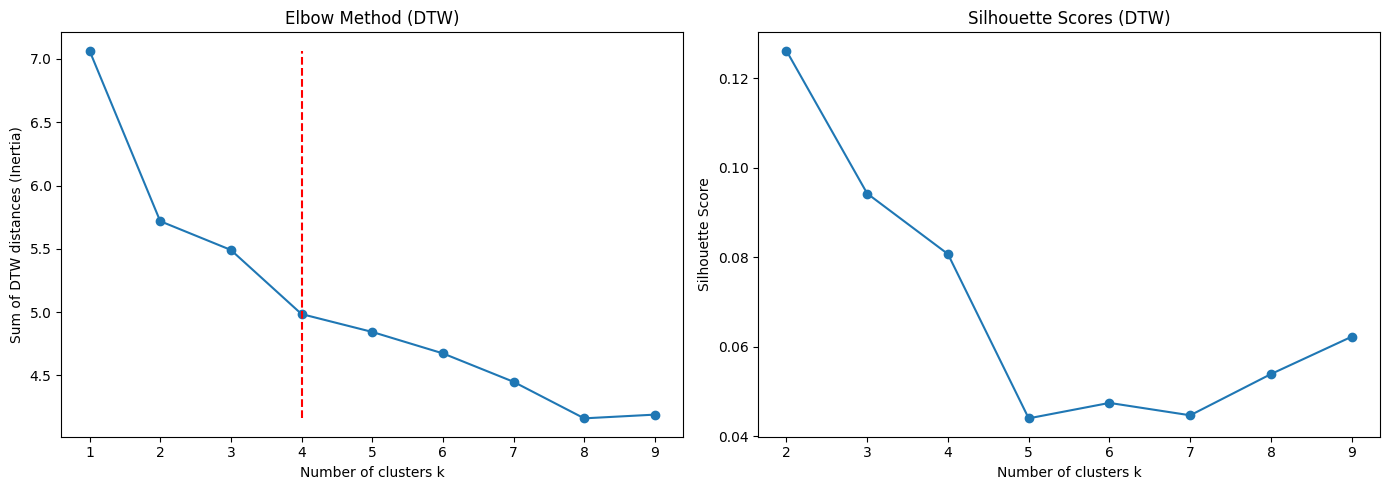

In [16]:
# 1. Import libraries
# -----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


df=pd.read_csv('input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_4_0.01', index_col=0, sep='\t')
print("Shape of dataset:", df.shape)

# -----------------------
# 3. Scale row-wise
# -----------------------
# tslearn expects 3D array: (n_samples, n_timestamps, n_features)
X = df.values[:, :, np.newaxis]  # add 3rd dimension
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# Convert X_scaled to 2D for DataFrame/plotting: (n_genes, n_samples)
X_scaled_2d = X_scaled[:, :, 0]
scaled_df = pd.DataFrame(X_scaled_2d, index=df.index, columns=df.columns)

sz = X_scaled.shape[1]  # number of time points (samples)
print("Number of time points:", sz)

sse = []
sil_scores = []
k_range = range(1, 10)

for k in k_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=42, n_init=2)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    
    if k > 1:
        dist_matrix = cdist_dtw(X_scaled)
        score = silhouette_score(dist_matrix, labels, metric='precomputed')
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

# -----------------------
# 4. Detect elbow
# -----------------------
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
print("Suggested k (elbow method):", knee.knee)

# -----------------------
# 5. Plot elbow and silhouette side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
axes[0].set_title("Elbow Method (DTW)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Sum of DTW distances (Inertia)")

# Silhouette plot
axes[1].plot(k_range[1:], sil_scores[1:], marker='o')
axes[1].set_title("Silhouette Scores (DTW)")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(range(2, 10))

plt.tight_layout()
plt.show()

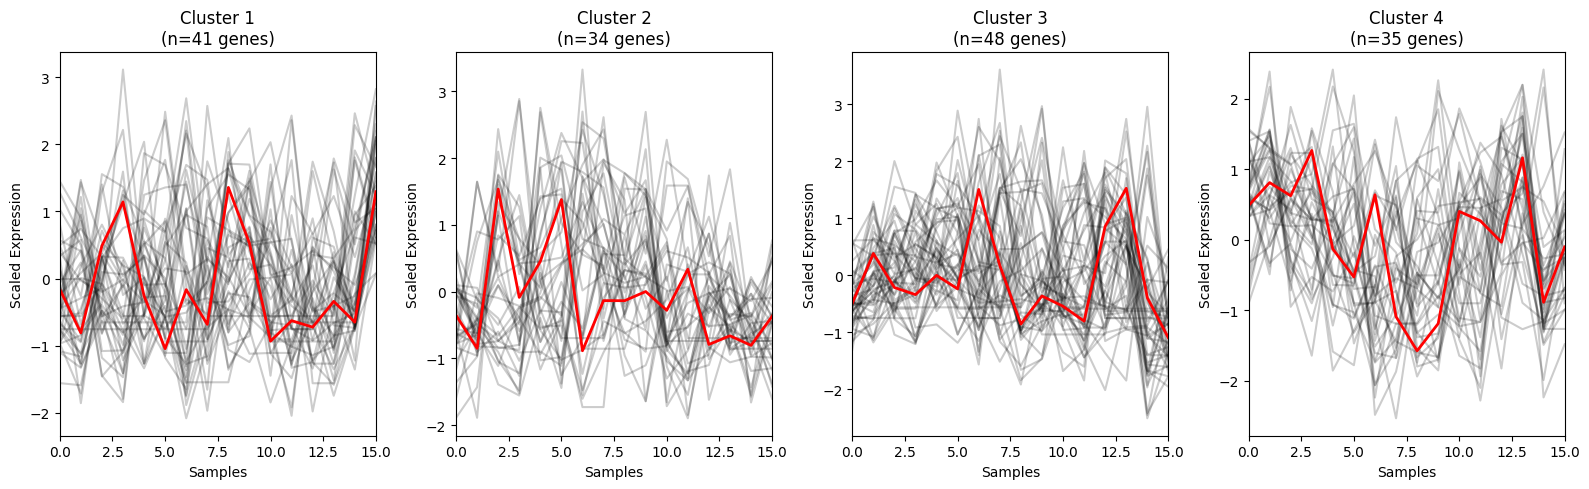

Silhouette Score (DTW) for k=4: 0.0807


In [17]:
# DTW Clustering
# -----------------------
n_clusters = 4  # choose your k
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42, n_init=2, max_iter_barycenter=10)
labels = km.fit_predict(X_scaled)

scaled_df['cluster'] = labels

# -----------------------
# 4. Plot clusters (scaled data)
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for _, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot DTW barycenter in red
    plt.plot(km.cluster_centers_[cluster].ravel(), color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()

# -----------------------
# 5. Silhouette Score (Euclidean on scaled data)
# -----------------------
dtw_dist_matrix = cdist_dtw(X_scaled)  # shape: (n_genes, n_genes)

#  Compute silhouette score with precomputed distances
score = silhouette_score(dtw_dist_matrix, labels, metric='precomputed')

print(f"Silhouette Score (DTW) for k={len(np.unique(labels))}: {score:.4f}")


# Module 5, DTW

Shape of dataset: (136, 16)
Number of time points: 16
Suggested k (elbow method): 6


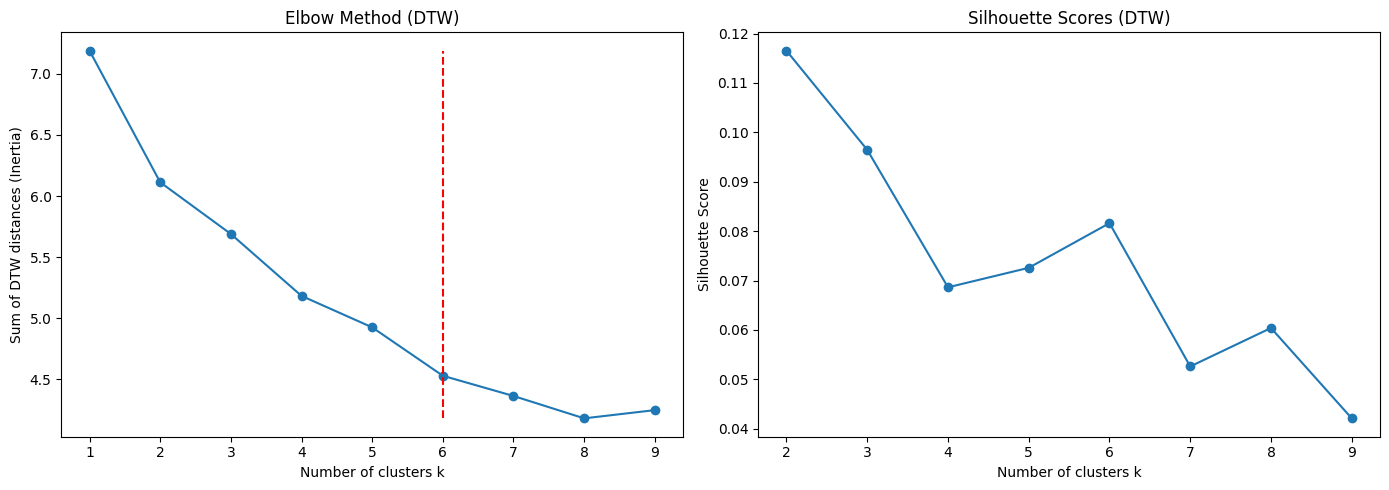

In [19]:
# 1. Import libraries
# -----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


df=pd.read_csv('input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_5_0.01', index_col=0, sep='\t')
print("Shape of dataset:", df.shape)

# -----------------------
# 3. Scale row-wise
# -----------------------
# tslearn expects 3D array: (n_samples, n_timestamps, n_features)
X = df.values[:, :, np.newaxis]  # add 3rd dimension
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# Convert X_scaled to 2D for DataFrame/plotting: (n_genes, n_samples)
X_scaled_2d = X_scaled[:, :, 0]
scaled_df = pd.DataFrame(X_scaled_2d, index=df.index, columns=df.columns)

sz = X_scaled.shape[1]  # number of time points (samples)
print("Number of time points:", sz)

sse = []
sil_scores = []
k_range = range(1, 10)

for k in k_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=42, n_init=2)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    
    if k > 1:
        dist_matrix = cdist_dtw(X_scaled)
        score = silhouette_score(dist_matrix, labels, metric='precomputed')
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

# -----------------------
# 4. Detect elbow
# -----------------------
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
print("Suggested k (elbow method):", knee.knee)

# -----------------------
# 5. Plot elbow and silhouette side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
axes[0].set_title("Elbow Method (DTW)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Sum of DTW distances (Inertia)")

# Silhouette plot
axes[1].plot(k_range[1:], sil_scores[1:], marker='o')
axes[1].set_title("Silhouette Scores (DTW)")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(range(2, 10))

plt.tight_layout()
plt.show()

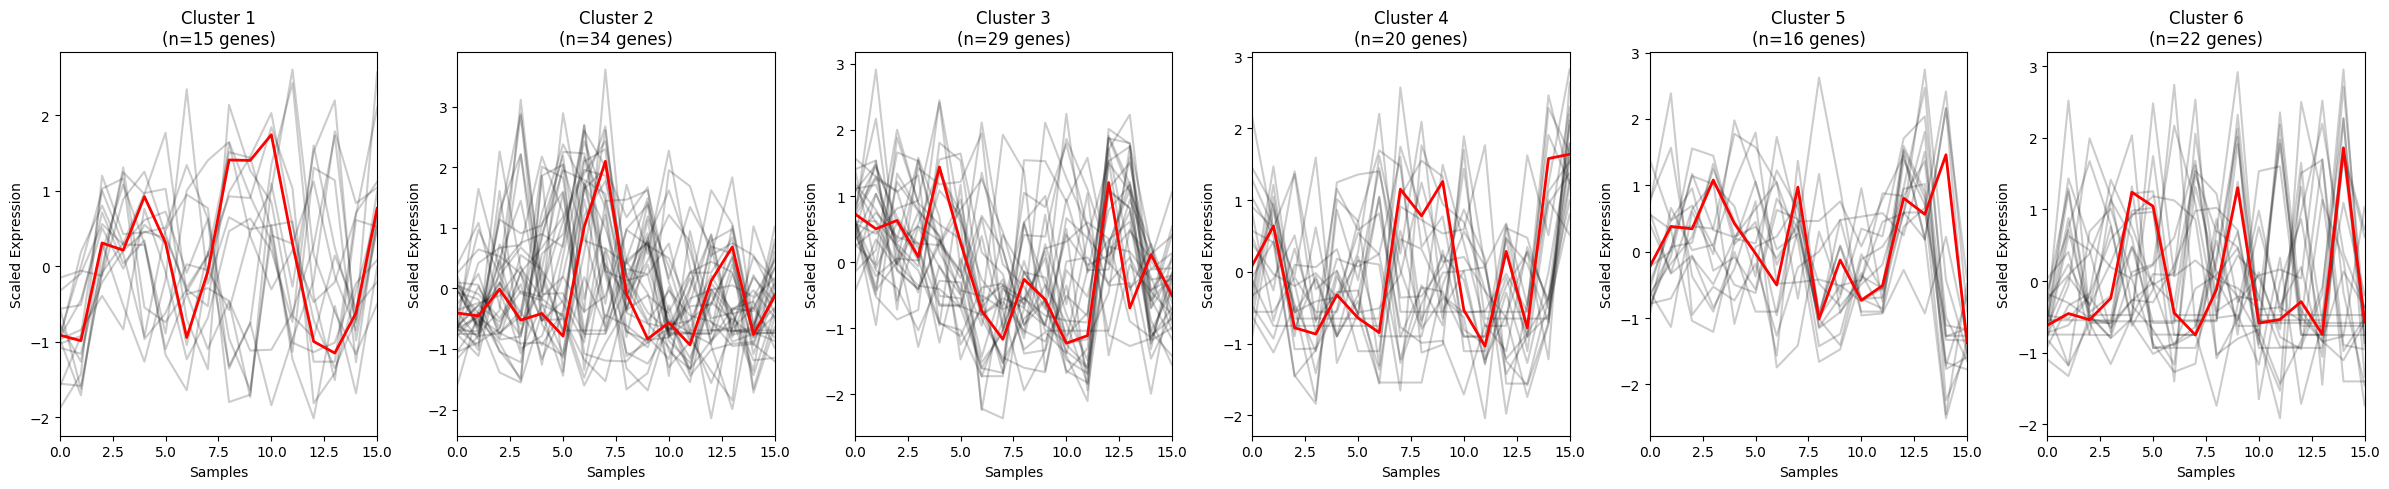

Silhouette Score (DTW) for k=6: 0.0816


In [20]:
# DTW Clustering
# -----------------------
n_clusters = 6  # choose your k
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42, n_init=2, max_iter_barycenter=10)
labels = km.fit_predict(X_scaled)

scaled_df['cluster'] = labels

# -----------------------
# 4. Plot clusters (scaled data)
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for _, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot DTW barycenter in red
    plt.plot(km.cluster_centers_[cluster].ravel(), color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()

# -----------------------
# 5. Silhouette Score (Euclidean on scaled data)
# -----------------------
dtw_dist_matrix = cdist_dtw(X_scaled)  # shape: (n_genes, n_genes)

#  Compute silhouette score with precomputed distances
score = silhouette_score(dtw_dist_matrix, labels, metric='precomputed')

print(f"Silhouette Score (DTW) for k={len(np.unique(labels))}: {score:.4f}")


# Module 6, DTW


Shape of dataset: (151, 16)
Number of time points: 16
Suggested k (elbow method): 4


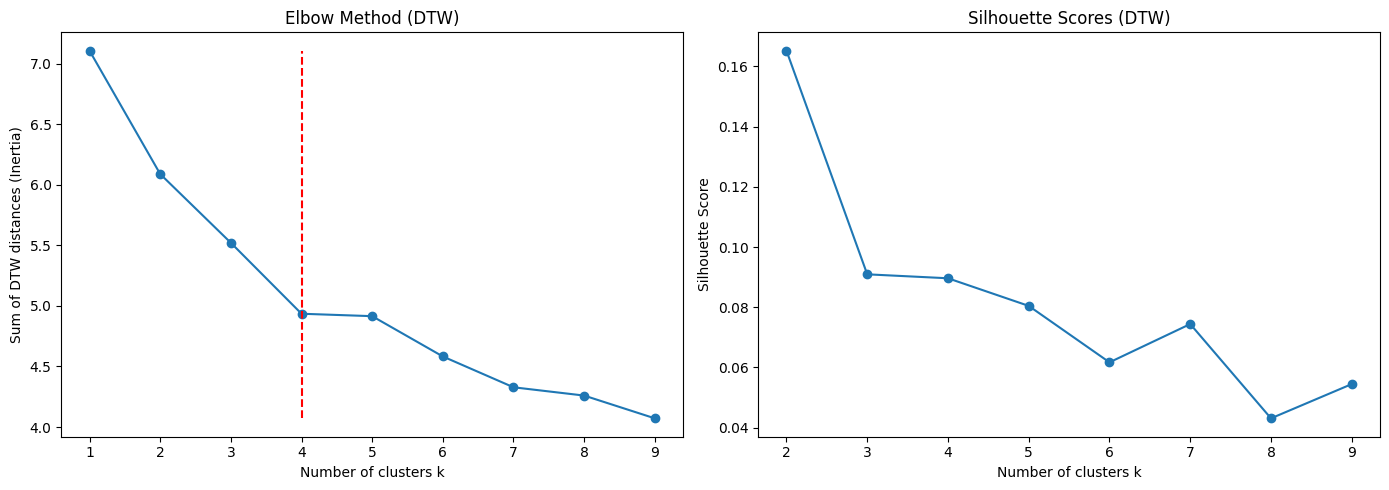

In [21]:
# 1. Import libraries
# -----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


df=pd.read_csv('input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_6_0.01', index_col=0, sep='\t')
print("Shape of dataset:", df.shape)

# -----------------------
# 3. Scale row-wise
# -----------------------
# tslearn expects 3D array: (n_samples, n_timestamps, n_features)
X = df.values[:, :, np.newaxis]  # add 3rd dimension
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# Convert X_scaled to 2D for DataFrame/plotting: (n_genes, n_samples)
X_scaled_2d = X_scaled[:, :, 0]
scaled_df = pd.DataFrame(X_scaled_2d, index=df.index, columns=df.columns)

sz = X_scaled.shape[1]  # number of time points (samples)
print("Number of time points:", sz)

sse = []
sil_scores = []
k_range = range(1, 10)

for k in k_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=42, n_init=2)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    
    if k > 1:
        dist_matrix = cdist_dtw(X_scaled)
        score = silhouette_score(dist_matrix, labels, metric='precomputed')
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

# -----------------------
# 4. Detect elbow
# -----------------------
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
print("Suggested k (elbow method):", knee.knee)

# -----------------------
# 5. Plot elbow and silhouette side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
axes[0].set_title("Elbow Method (DTW)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Sum of DTW distances (Inertia)")

# Silhouette plot
axes[1].plot(k_range[1:], sil_scores[1:], marker='o')
axes[1].set_title("Silhouette Scores (DTW)")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(range(2, 10))

plt.tight_layout()
plt.show()

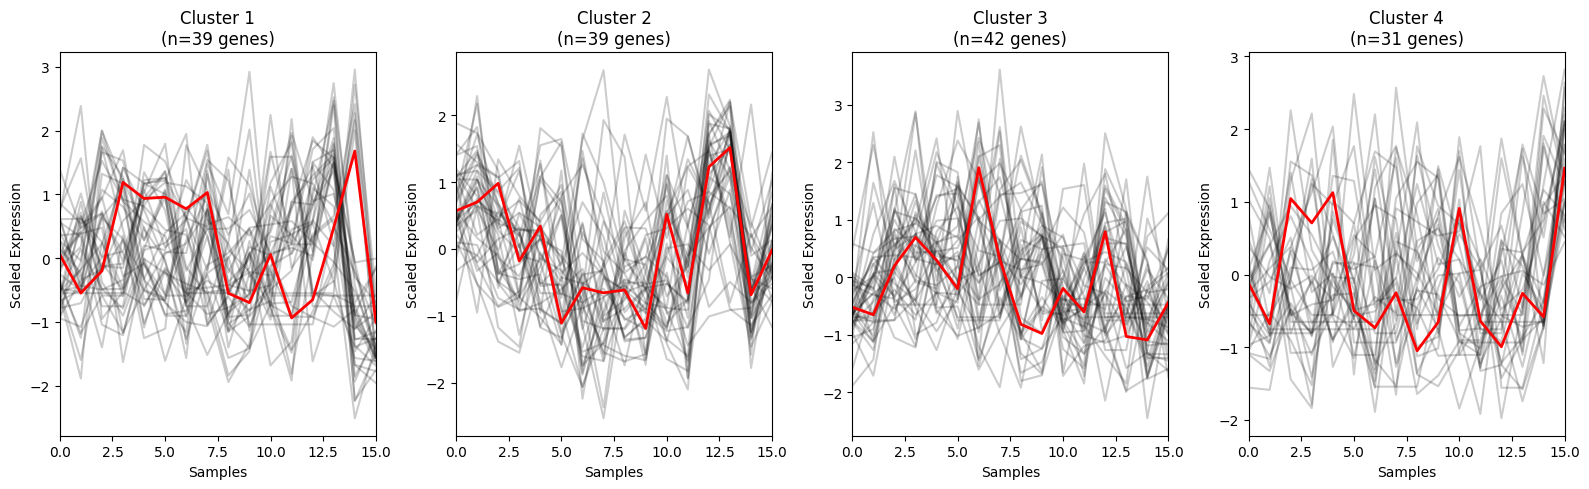

Silhouette Score (DTW) for k=4: 0.0896


In [22]:
# DTW Clustering
# -----------------------
n_clusters = 4  # choose your k
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42, n_init=2, max_iter_barycenter=10)
labels = km.fit_predict(X_scaled)

scaled_df['cluster'] = labels

# -----------------------
# 4. Plot clusters (scaled data)
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for _, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot DTW barycenter in red
    plt.plot(km.cluster_centers_[cluster].ravel(), color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()

# -----------------------
# 5. Silhouette Score (Euclidean on scaled data)
# -----------------------
dtw_dist_matrix = cdist_dtw(X_scaled)  # shape: (n_genes, n_genes)

#  Compute silhouette score with precomputed distances
score = silhouette_score(dtw_dist_matrix, labels, metric='precomputed')

print(f"Silhouette Score (DTW) for k={len(np.unique(labels))}: {score:.4f}")


# Module 7, DTW

Shape of dataset: (91, 16)
Number of time points: 16
Suggested k (elbow method): 3


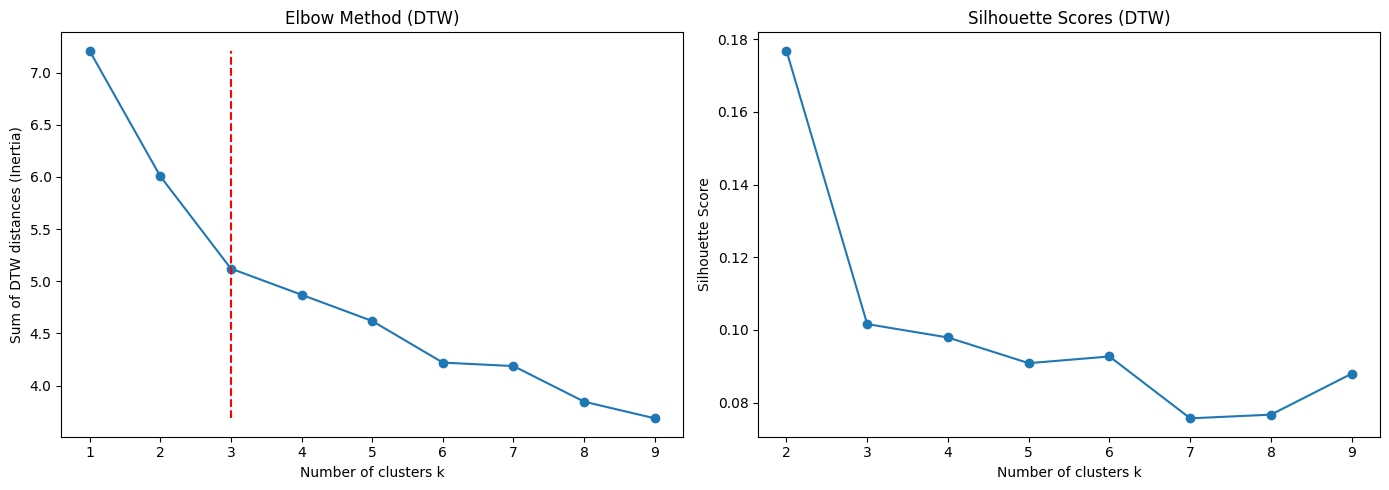

In [23]:
# 1. Import libraries
# -----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


df=pd.read_csv('input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_7_0.01', index_col=0, sep='\t')
print("Shape of dataset:", df.shape)

# -----------------------
# 3. Scale row-wise
# -----------------------
# tslearn expects 3D array: (n_samples, n_timestamps, n_features)
X = df.values[:, :, np.newaxis]  # add 3rd dimension
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# Convert X_scaled to 2D for DataFrame/plotting: (n_genes, n_samples)
X_scaled_2d = X_scaled[:, :, 0]
scaled_df = pd.DataFrame(X_scaled_2d, index=df.index, columns=df.columns)

sz = X_scaled.shape[1]  # number of time points (samples)
print("Number of time points:", sz)

sse = []
sil_scores = []
k_range = range(1, 10)

for k in k_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=42, n_init=2)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    
    if k > 1:
        dist_matrix = cdist_dtw(X_scaled)
        score = silhouette_score(dist_matrix, labels, metric='precomputed')
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

# -----------------------
# 4. Detect elbow
# -----------------------
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
print("Suggested k (elbow method):", knee.knee)

# -----------------------
# 5. Plot elbow and silhouette side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
axes[0].set_title("Elbow Method (DTW)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Sum of DTW distances (Inertia)")

# Silhouette plot
axes[1].plot(k_range[1:], sil_scores[1:], marker='o')
axes[1].set_title("Silhouette Scores (DTW)")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(range(2, 10))

plt.tight_layout()
plt.show()

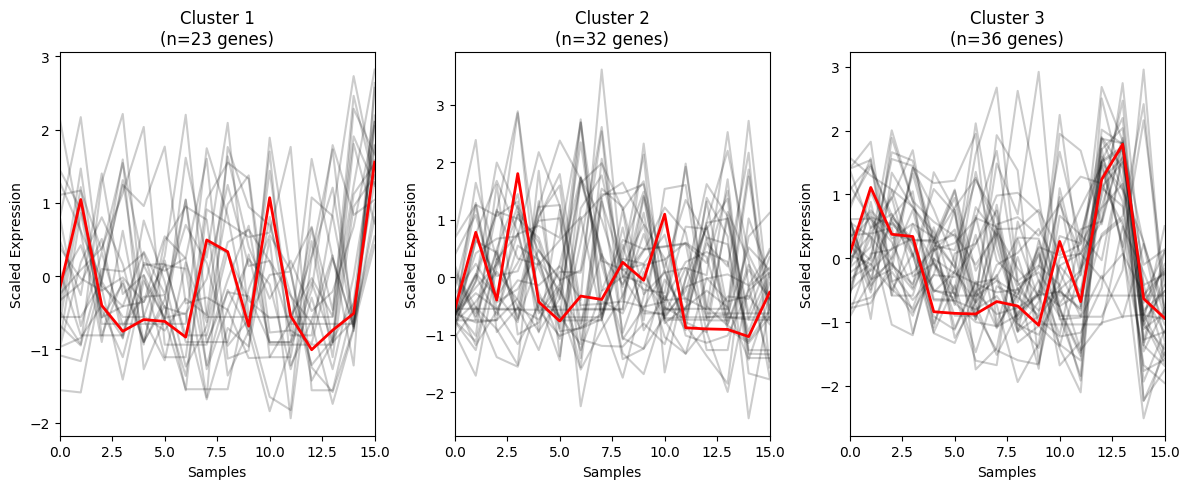

Silhouette Score (DTW) for k=3: 0.1016


In [24]:
# DTW Clustering
# -----------------------
n_clusters = 3  # choose your k
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42, n_init=2, max_iter_barycenter=10)
labels = km.fit_predict(X_scaled)

scaled_df['cluster'] = labels

# -----------------------
# 4. Plot clusters (scaled data)
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for _, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot DTW barycenter in red
    plt.plot(km.cluster_centers_[cluster].ravel(), color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()

# -----------------------
# 5. Silhouette Score (Euclidean on scaled data)
# -----------------------
dtw_dist_matrix = cdist_dtw(X_scaled)  # shape: (n_genes, n_genes)

#  Compute silhouette score with precomputed distances
score = silhouette_score(dtw_dist_matrix, labels, metric='precomputed')

print(f"Silhouette Score (DTW) for k={len(np.unique(labels))}: {score:.4f}")


# Hierarchical clustering, module 3

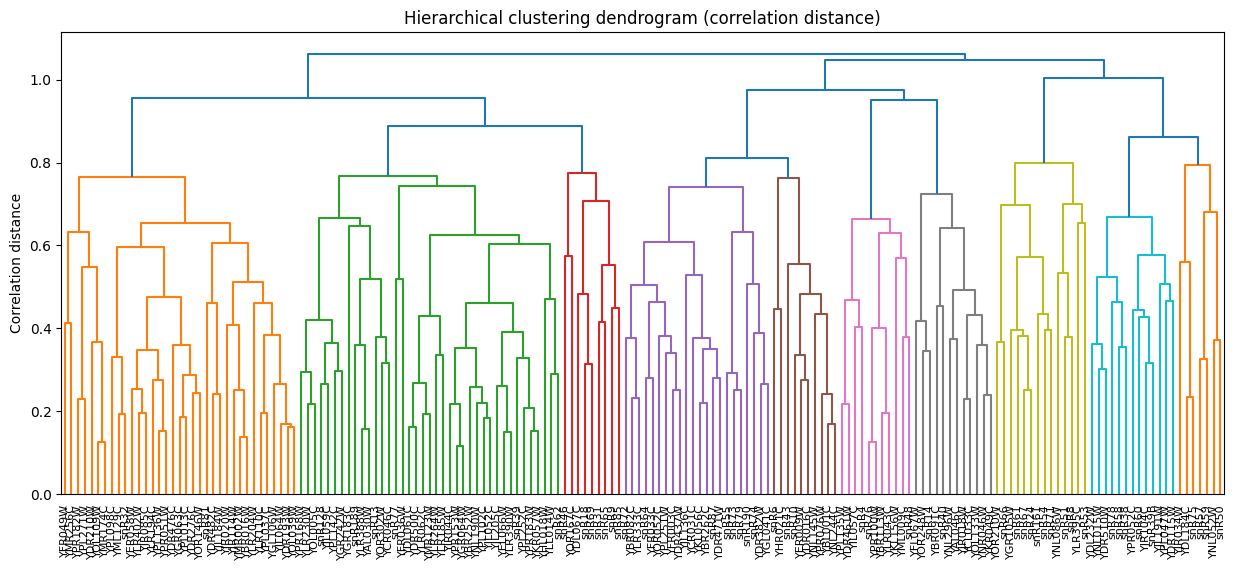

Silhouette score for k=2: 0.156
Silhouette score for k=3: 0.146
Silhouette score for k=4: 0.138
Silhouette score for k=5: 0.131
Silhouette score for k=6: 0.160
Silhouette score for k=7: 0.158
Silhouette score for k=8: 0.155
Silhouette score for k=9: 0.155
Silhouette score for k=10: 0.162
Silhouette score for k=11: 0.162
Silhouette score for k=12: 0.156
Silhouette score for k=13: 0.152
Silhouette score for k=14: 0.153
Silhouette score for k=15: 0.154


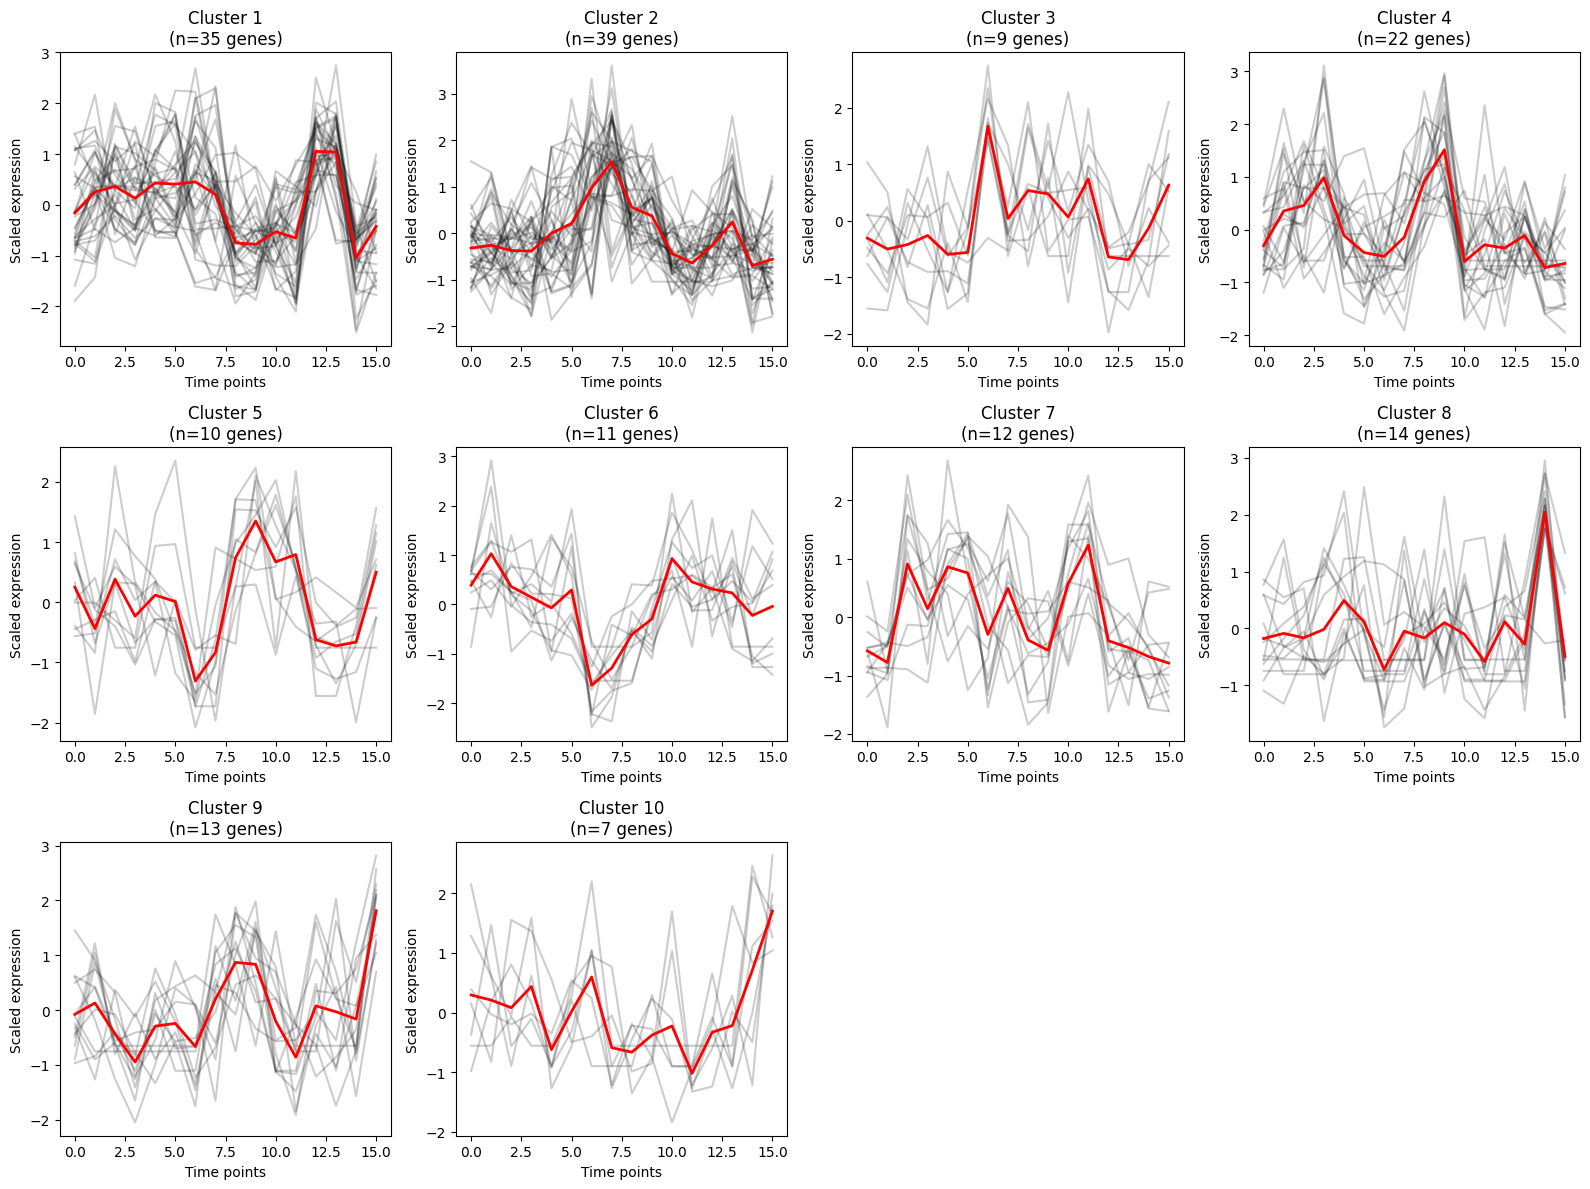

Average silhouette score = 0.1616


In [25]:
import pandas as pd
import numpy as np
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import math

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_3_0.01',
    index_col=0, sep='\t'
)
X = df.values  # genes x 16 timepoints

# -----------------------
# 2. Scale each gene (optional but recommended)
# -----------------------
X_scaled = X.reshape(X.shape[0], X.shape[1], 1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_scaled)
X_scaled_2d = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])

# -----------------------
# 3. Compute correlation distance
# -----------------------
corr = np.corrcoef(X_scaled_2d)
dist = 1 - corr  # correlation-based distance

# -----------------------
# 4. Hierarchical clustering
# -----------------------
# linkage expects a condensed distance matrix, so flatten the upper triangle
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist, checks=False)

# Perform hierarchical clustering (average linkage is common)
Z = linkage(condensed_dist, method='average')

# -----------------------
# 5. Plot dendrogram
# -----------------------
plt.figure(figsize=(15, 6))
dendrogram(Z, labels=df.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.8)
plt.title("Hierarchical clustering dendrogram (correlation distance)")
plt.ylabel("Correlation distance")
plt.show()

# -----------------------
# 6. Silhouette analysis for different k
# -----------------------
silhouette_scores = {}
for k in range(2, 16):  # test k from 2 to 15
    cluster_labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(dist, cluster_labels, metric="precomputed")
    silhouette_scores[k] = score
    print(f"Silhouette score for k={k}: {score:.3f}")
# -----------------------
# 6. Assign clusters
# -----------------------
n_clusters = 10 # choose based on dendrogram or desired number of clusters
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# -----------------------
# 7. Plot line profiles per cluster
# -----------------------


# Determine number of rows and columns
cols = 4
rows = math.ceil(n_clusters / cols)

plt.figure(figsize=(cols * 4, rows * 4))  # scale figure size with number of cols/rows

for yi in range(1, n_clusters + 1):
    ax = plt.subplot(rows, cols, yi)
    
    cluster_data = X_scaled_2d[cluster_labels == yi]
    
    # Plot all genes in black
    for xx in cluster_data:
        plt.plot(xx.ravel(), "k-", alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.ravel(), "r-", linewidth=2)
    
    plt.title(f"Cluster {yi}\n(n={cluster_data.shape[0]} genes)")
    plt.xlabel("Time points")
    plt.ylabel("Scaled expression")

plt.tight_layout()
plt.show()

# Silhouette score
silhouette_avg = silhouette_score(dist, cluster_labels, metric="precomputed")
print(f"Average silhouette score = {silhouette_avg:.4f}")

# export cluster assignments together with time series data
cluster_df = df.copy()
cluster_df['cluster'] = cluster_labels
cluster_df.to_csv('hierarchical_clustering_clusters_m3.csv', index=True)

# Hierarchical clustering
## module 4

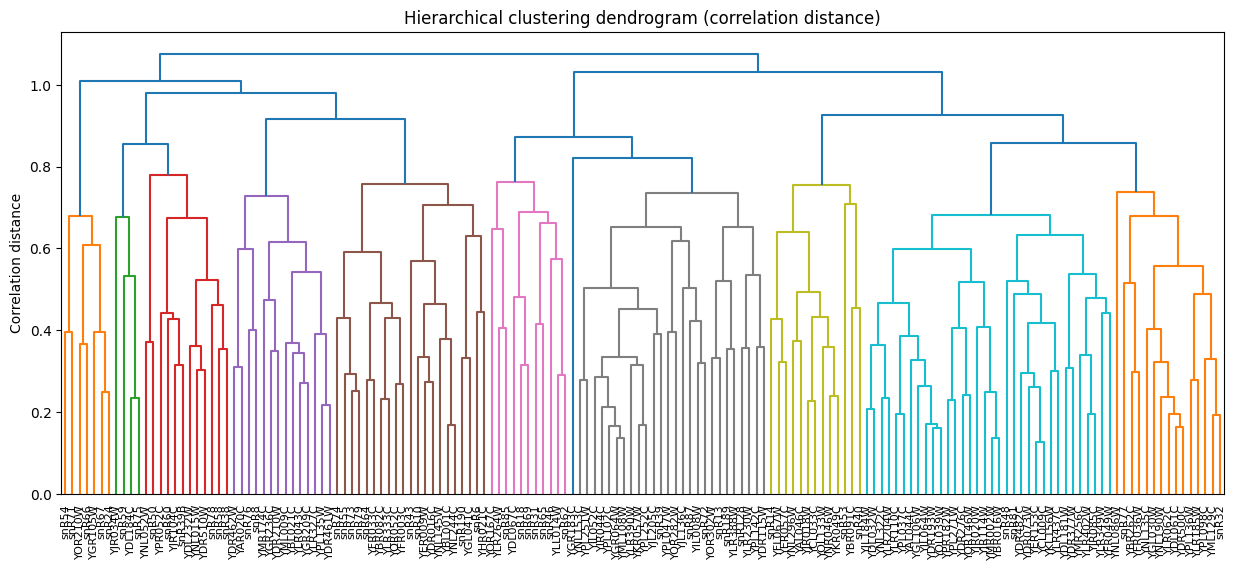

Silhouette score for k=2: 0.163
Silhouette score for k=3: 0.158
Silhouette score for k=4: 0.144
Silhouette score for k=5: 0.149
Silhouette score for k=6: 0.146
Silhouette score for k=7: 0.151
Silhouette score for k=8: 0.153
Silhouette score for k=9: 0.165
Silhouette score for k=10: 0.162
Silhouette score for k=11: 0.134
Silhouette score for k=12: 0.125
Silhouette score for k=13: 0.125
Silhouette score for k=14: 0.131
Silhouette score for k=15: 0.127


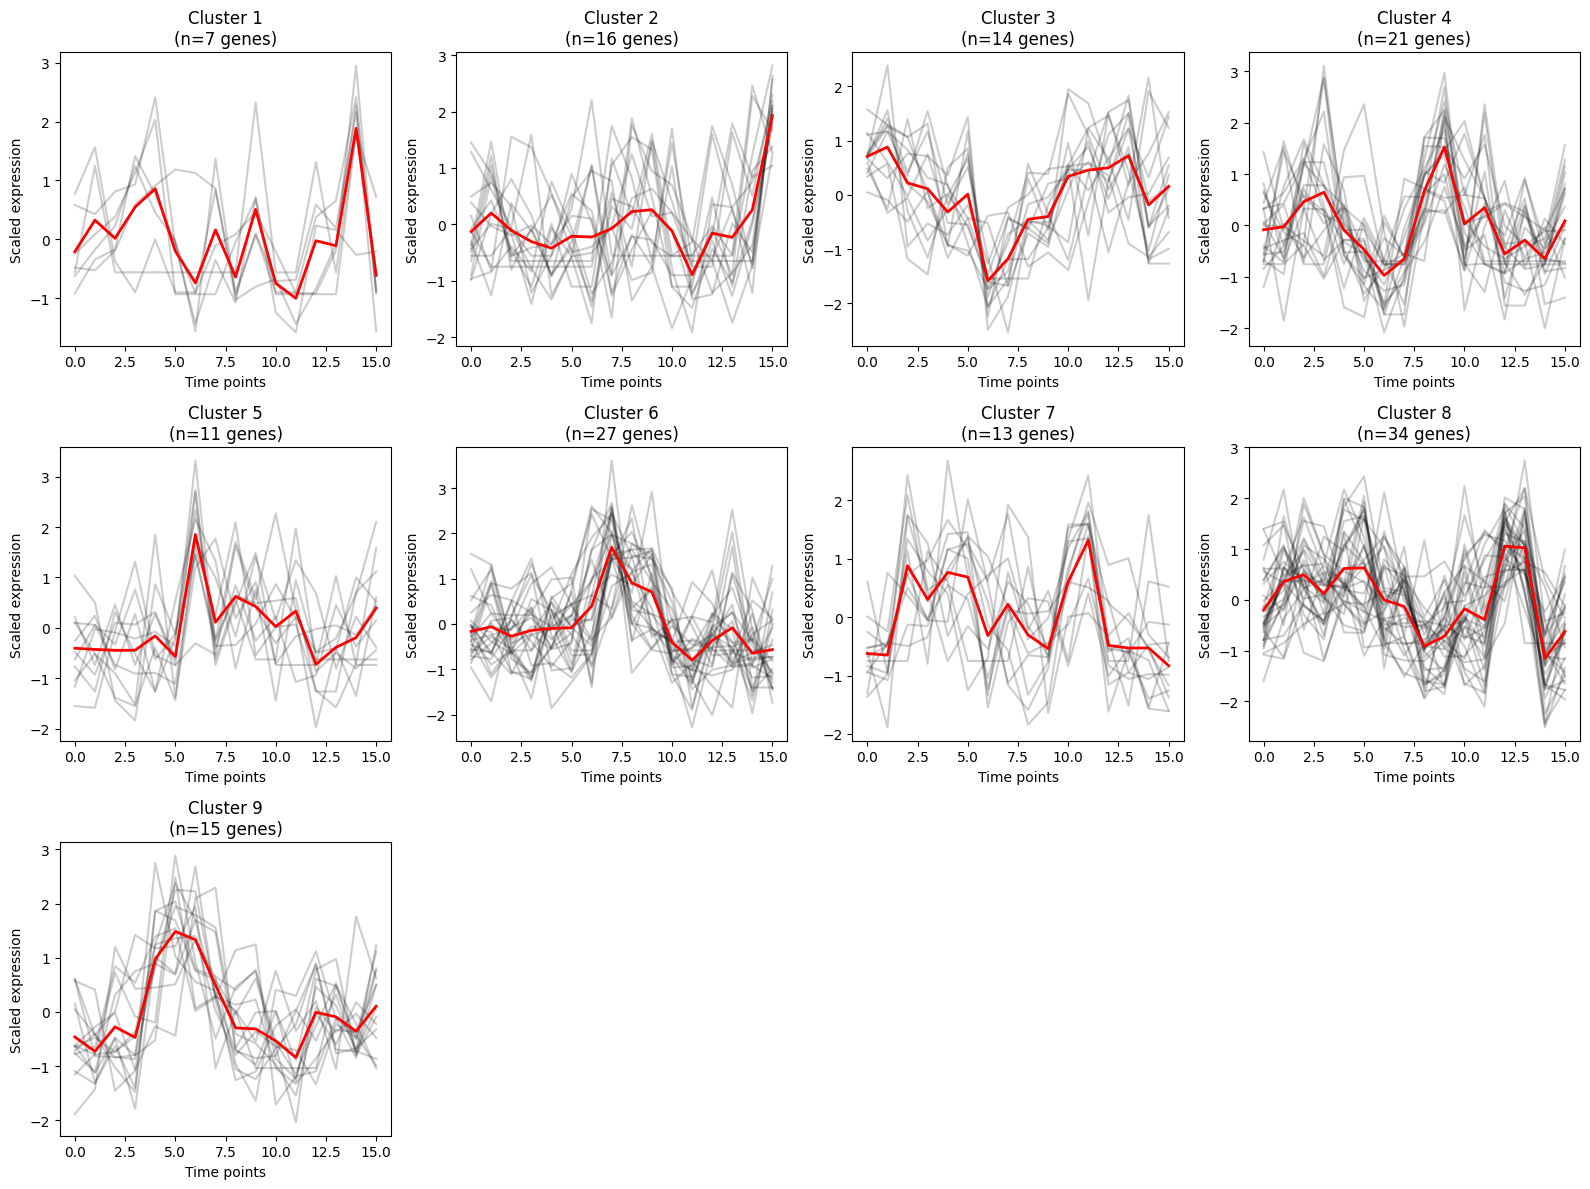

Average silhouette score = 0.1647


In [26]:
import pandas as pd
import numpy as np
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import math

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_4_0.01',
    index_col=0, sep='\t'
)
X = df.values  # genes x 16 timepoints

# -----------------------
# 2. Scale each gene (optional but recommended)
# -----------------------
X_scaled = X.reshape(X.shape[0], X.shape[1], 1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_scaled)
X_scaled_2d = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])

# -----------------------
# 3. Compute correlation distance
# -----------------------
corr = np.corrcoef(X_scaled_2d)
dist = 1 - corr  # correlation-based distance

# -----------------------
# 4. Hierarchical clustering
# -----------------------
# linkage expects a condensed distance matrix, so flatten the upper triangle
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist, checks=False)

# Perform hierarchical clustering (average linkage is common)
Z = linkage(condensed_dist, method='average')

# -----------------------
# 5. Plot dendrogram
# -----------------------
plt.figure(figsize=(15, 6))
dendrogram(Z, labels=df.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.8)
plt.title("Hierarchical clustering dendrogram (correlation distance)")
plt.ylabel("Correlation distance")
plt.show()

# -----------------------
# 6. Silhouette analysis for different k
# -----------------------
silhouette_scores = {}
for k in range(2, 16):  # test k from 2 to 15
    cluster_labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(dist, cluster_labels, metric="precomputed")
    silhouette_scores[k] = score
    print(f"Silhouette score for k={k}: {score:.3f}")

# -----------------------
# 6. Assign clusters
# -----------------------
n_clusters = 9 # choose based on dendrogram or desired number of clusters
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# -----------------------
# 7. Plot line profiles per cluster
# -----------------------


# Determine number of rows and columns
cols = 4
rows = math.ceil(n_clusters / cols)

plt.figure(figsize=(cols * 4, rows * 4))  # scale figure size with number of cols/rows

for yi in range(1, n_clusters + 1):
    ax = plt.subplot(rows, cols, yi)
    
    cluster_data = X_scaled_2d[cluster_labels == yi]
    
    # Plot all genes in black
    for xx in cluster_data:
        plt.plot(xx.ravel(), "k-", alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.ravel(), "r-", linewidth=2)
    
    plt.title(f"Cluster {yi}\n(n={cluster_data.shape[0]} genes)")
    plt.xlabel("Time points")
    plt.ylabel("Scaled expression")

plt.tight_layout()
plt.show()

# Silhouette score
silhouette_avg = silhouette_score(dist, cluster_labels, metric="precomputed")
print(f"Average silhouette score = {silhouette_avg:.4f}")
# export cluster assignments together with time series data
cluster_df = df.copy()
cluster_df['cluster'] = cluster_labels
cluster_df.to_csv('hierarchical_clustering_clusters_m4.csv', index=True)

# Hierarchical clustering
## Module 5

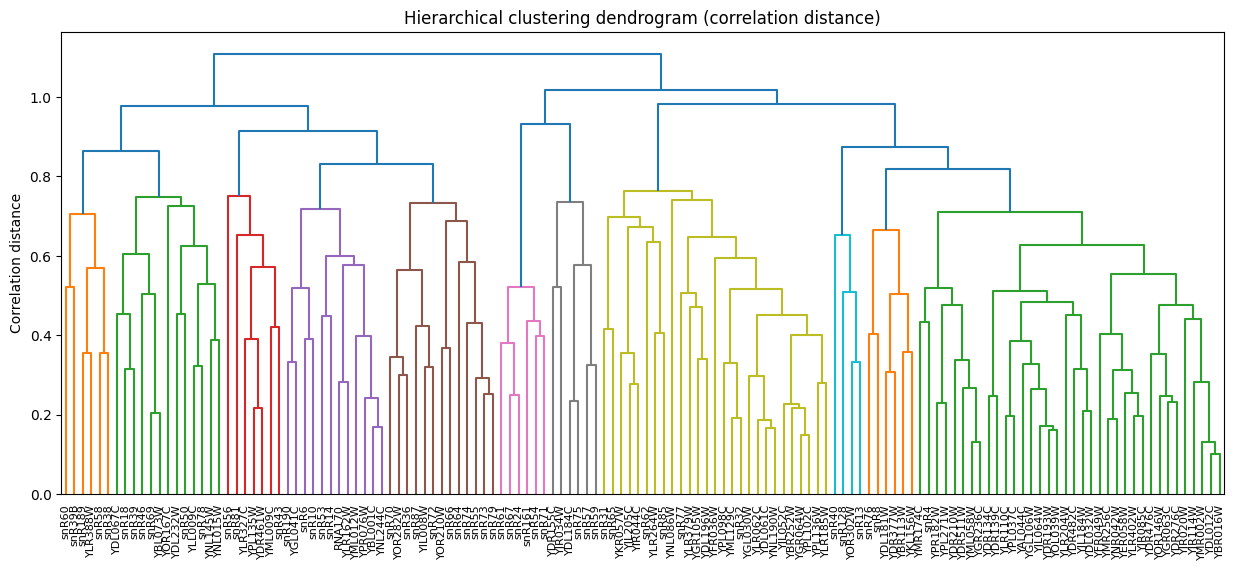

Silhouette score for k=2: 0.205
Silhouette score for k=3: 0.157
Silhouette score for k=4: 0.169
Silhouette score for k=5: 0.174
Silhouette score for k=6: 0.164
Silhouette score for k=7: 0.154
Silhouette score for k=8: 0.142
Silhouette score for k=9: 0.146
Silhouette score for k=10: 0.159
Silhouette score for k=11: 0.158
Silhouette score for k=12: 0.153
Silhouette score for k=13: 0.135
Silhouette score for k=14: 0.139
Silhouette score for k=15: 0.120


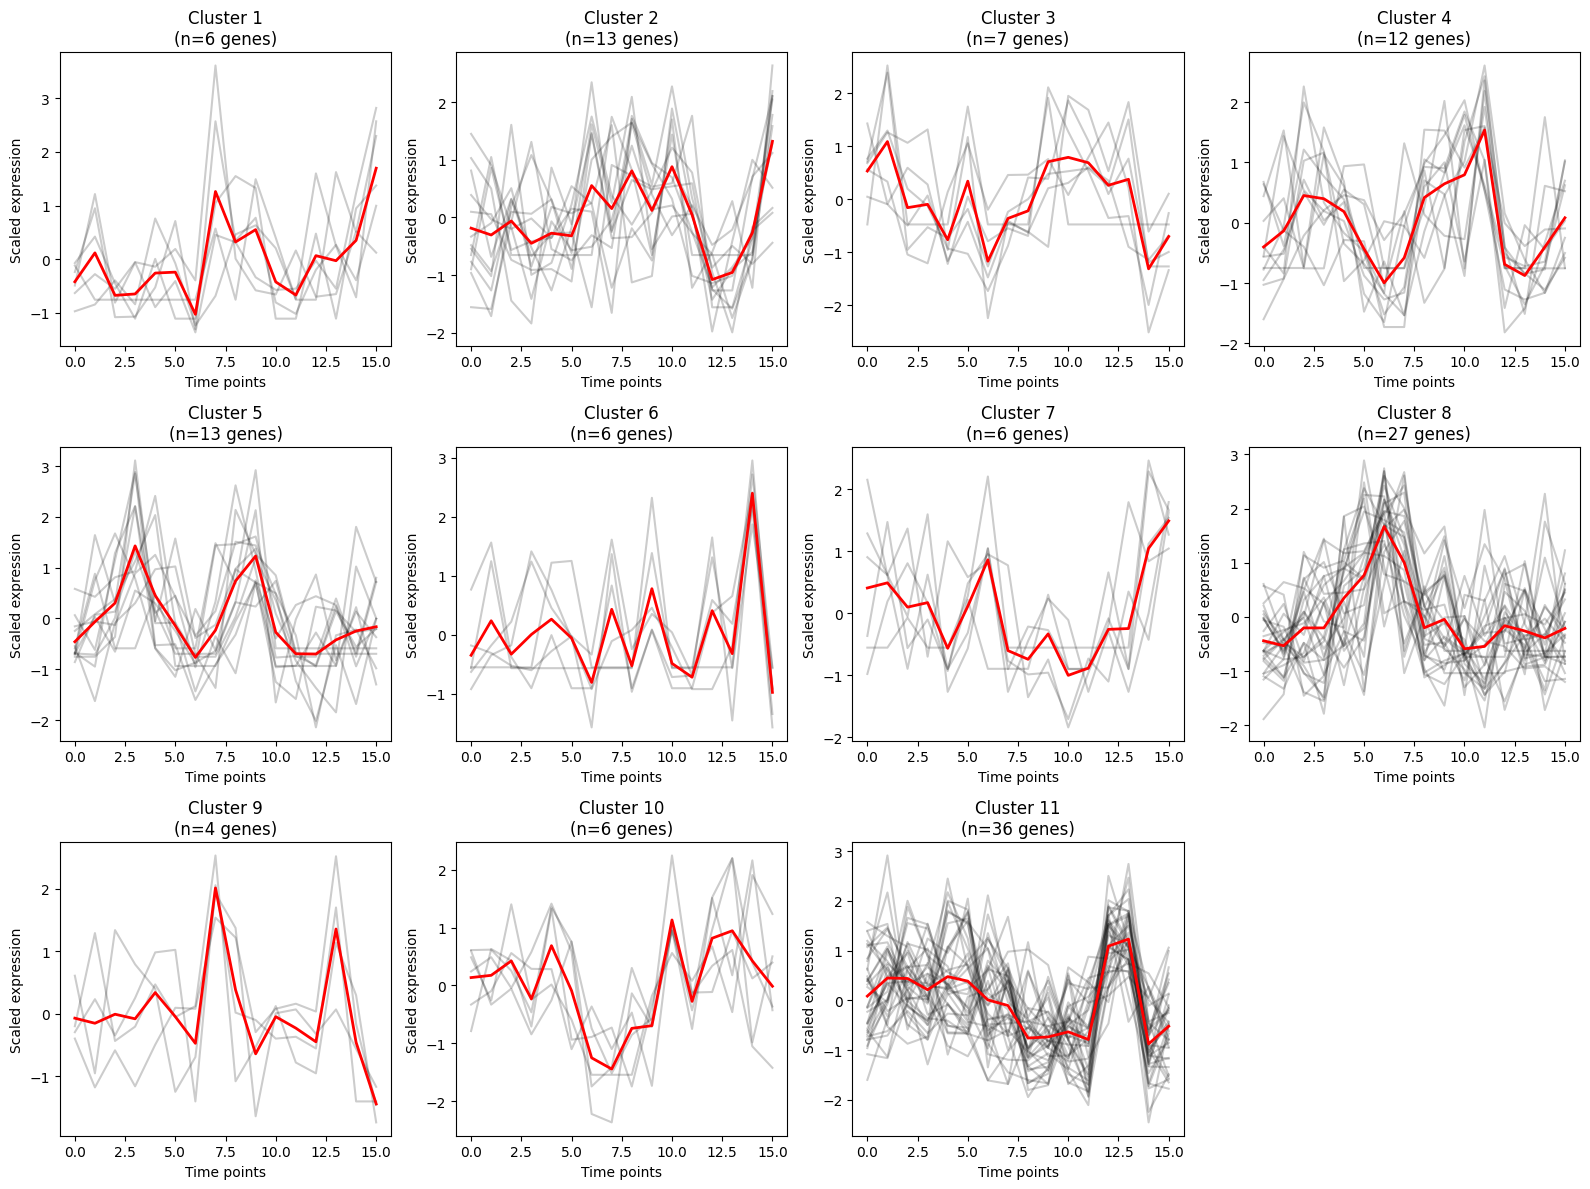

Average silhouette score = 0.1576


In [27]:
import pandas as pd
import numpy as np
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import math

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_5_0.01',
    index_col=0, sep='\t'
)
X = df.values  # genes x 16 timepoints

# -----------------------
# 2. Scale each gene (optional but recommended)
# -----------------------
X_scaled = X.reshape(X.shape[0], X.shape[1], 1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_scaled)
X_scaled_2d = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])

# -----------------------
# 3. Compute correlation distance
# -----------------------
corr = np.corrcoef(X_scaled_2d)
dist = 1 - corr  # correlation-based distance

# -----------------------
# 4. Hierarchical clustering
# -----------------------
# linkage expects a condensed distance matrix, so flatten the upper triangle
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist, checks=False)

# Perform hierarchical clustering (average linkage is common)
Z = linkage(condensed_dist, method='average')

# -----------------------
# 5. Plot dendrogram
# -----------------------
plt.figure(figsize=(15, 6))
dendrogram(Z, labels=df.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.8)
plt.title("Hierarchical clustering dendrogram (correlation distance)")
plt.ylabel("Correlation distance")
plt.show()

# -----------------------
# 6. Silhouette analysis for different k
# -----------------------
silhouette_scores = {}
for k in range(2, 16):  # test k from 2 to 15
    cluster_labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(dist, cluster_labels, metric="precomputed")
    silhouette_scores[k] = score
    print(f"Silhouette score for k={k}: {score:.3f}")

# -----------------------
# 6. Assign clusters
# -----------------------
n_clusters = 11 # choose based on dendrogram or desired number of clusters
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# -----------------------
# 7. Plot line profiles per cluster
# -----------------------


# Determine number of rows and columns
cols = 4
rows = math.ceil(n_clusters / cols)

plt.figure(figsize=(cols * 4, rows * 4))  # scale figure size with number of cols/rows

for yi in range(1, n_clusters + 1):
    ax = plt.subplot(rows, cols, yi)
    
    cluster_data = X_scaled_2d[cluster_labels == yi]
    
    # Plot all genes in black
    for xx in cluster_data:
        plt.plot(xx.ravel(), "k-", alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.ravel(), "r-", linewidth=2)
    
    plt.title(f"Cluster {yi}\n(n={cluster_data.shape[0]} genes)")
    plt.xlabel("Time points")
    plt.ylabel("Scaled expression")

plt.tight_layout()
plt.show()

# Silhouette score
silhouette_avg = silhouette_score(dist, cluster_labels, metric="precomputed")
print(f"Average silhouette score = {silhouette_avg:.4f}")

# export cluster assignments together with time series data
cluster_df = df.copy()
cluster_df['cluster'] = cluster_labels
cluster_df.to_csv('hierarchical_clustering_clusters_m5.csv', index=True)

# Hierarchical clustering
# Module 6

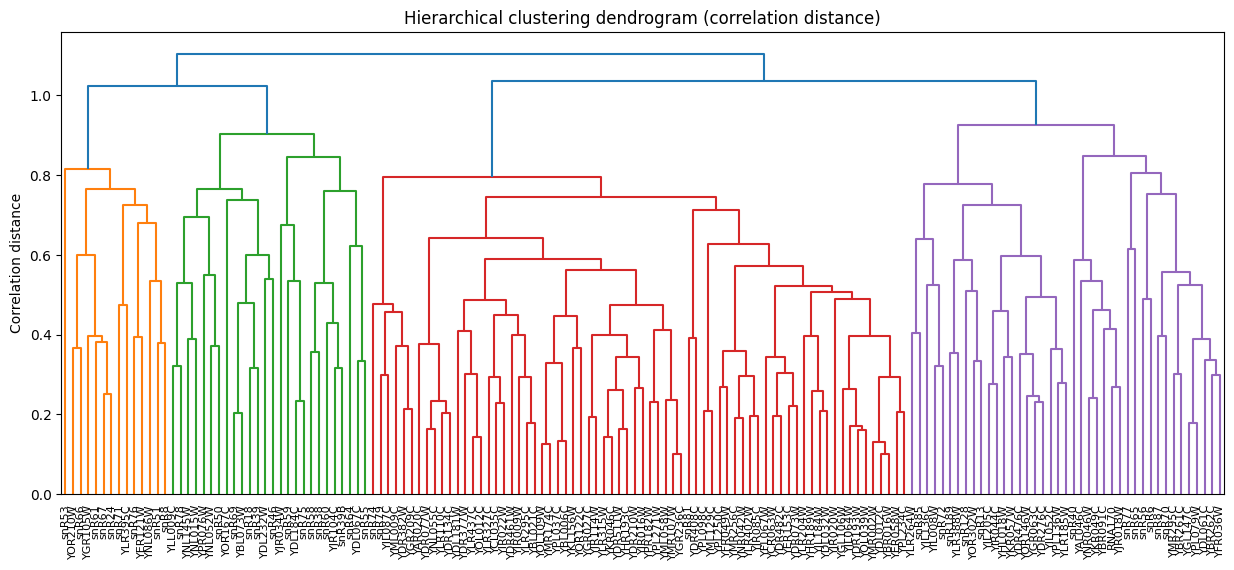

Silhouette score for k=2: 0.204
Silhouette score for k=3: 0.215
Silhouette score for k=4: 0.216
Silhouette score for k=5: 0.211
Silhouette score for k=6: 0.212
Silhouette score for k=7: 0.189
Silhouette score for k=8: 0.184
Silhouette score for k=9: 0.165
Silhouette score for k=10: 0.154
Silhouette score for k=11: 0.119
Silhouette score for k=12: 0.115
Silhouette score for k=13: 0.121
Silhouette score for k=14: 0.127
Silhouette score for k=15: 0.129


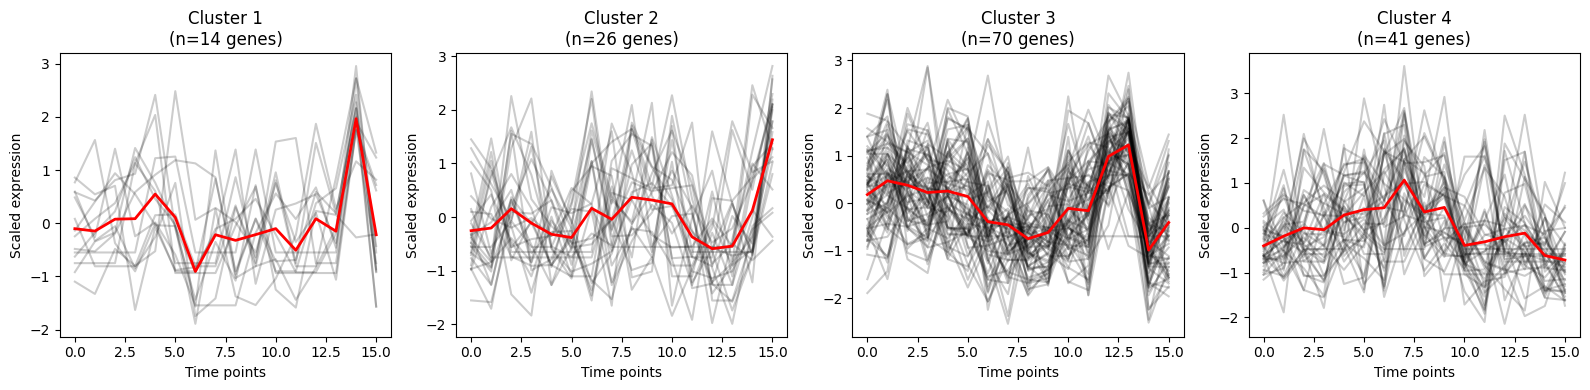

Average silhouette score = 0.2159


In [28]:
import pandas as pd
import numpy as np
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import math

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_6_0.01',
    index_col=0, sep='\t'
)
X = df.values  # genes x 16 timepoints

# -----------------------
# 2. Scale each gene (optional but recommended)
# -----------------------
X_scaled = X.reshape(X.shape[0], X.shape[1], 1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_scaled)
X_scaled_2d = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])

# -----------------------
# 3. Compute correlation distance
# -----------------------
corr = np.corrcoef(X_scaled_2d)
dist = 1 - corr  # correlation-based distance

# -----------------------
# 4. Hierarchical clustering
# -----------------------
# linkage expects a condensed distance matrix, so flatten the upper triangle
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist, checks=False)

# Perform hierarchical clustering (average linkage is common)
Z = linkage(condensed_dist, method='average')

# -----------------------
# 5. Plot dendrogram
# -----------------------
plt.figure(figsize=(15, 6))
dendrogram(Z, labels=df.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.95)
plt.title("Hierarchical clustering dendrogram (correlation distance)")
plt.ylabel("Correlation distance")
plt.show()

# -----------------------
# 6. Silhouette analysis for different k
# -----------------------
silhouette_scores = {}
for k in range(2, 16):  # test k from 2 to 15
    cluster_labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(dist, cluster_labels, metric="precomputed")
    silhouette_scores[k] = score
    print(f"Silhouette score for k={k}: {score:.3f}")


# -----------------------
# 6. Assign clusters
# -----------------------
n_clusters = 4 # choose based on dendrogram or desired number of clusters
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# -----------------------
# 7. Plot line profiles per cluster
# -----------------------


# Determine number of rows and columns
cols = 4
rows = math.ceil(n_clusters / cols)

plt.figure(figsize=(cols * 4, rows * 4))  # scale figure size with number of cols/rows

for yi in range(1, n_clusters + 1):
    ax = plt.subplot(rows, cols, yi)
    
    cluster_data = X_scaled_2d[cluster_labels == yi]
    
    # Plot all genes in black
    for xx in cluster_data:
        plt.plot(xx.ravel(), "k-", alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.ravel(), "r-", linewidth=2)
    
    plt.title(f"Cluster {yi}\n(n={cluster_data.shape[0]} genes)")
    plt.xlabel("Time points")
    plt.ylabel("Scaled expression")

plt.tight_layout()
plt.show()

# Silhouette score
silhouette_avg = silhouette_score(dist, cluster_labels, metric="precomputed")
print(f"Average silhouette score = {silhouette_avg:.4f}")
# export cluster assignments together with time series data
cluster_df = df.copy()
cluster_df['cluster'] = cluster_labels
cluster_df.to_csv('hierarchical_clustering_clusters_m6.csv', index=True)

# Hierarchical clustering, module 7

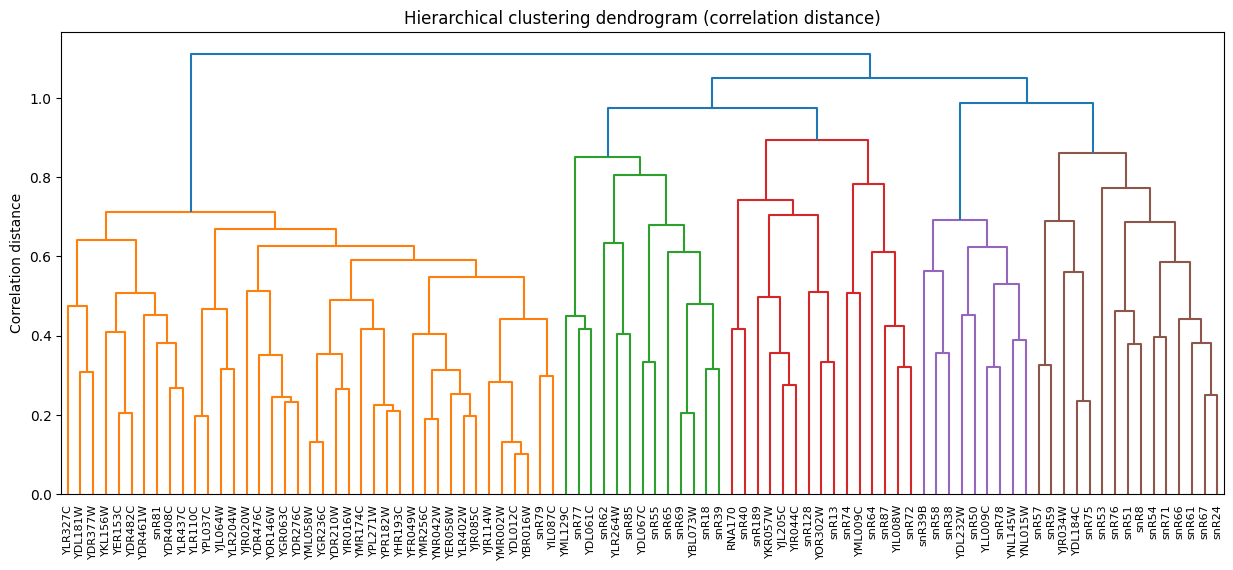

Silhouette score for k=2: 0.254
Silhouette score for k=3: 0.231
Silhouette score for k=4: 0.234
Silhouette score for k=5: 0.237
Silhouette score for k=6: 0.220
Silhouette score for k=7: 0.222
Silhouette score for k=8: 0.202
Silhouette score for k=9: 0.205
Silhouette score for k=10: 0.165
Silhouette score for k=11: 0.154
Silhouette score for k=12: 0.151
Silhouette score for k=13: 0.147
Silhouette score for k=14: 0.147
Silhouette score for k=15: 0.146


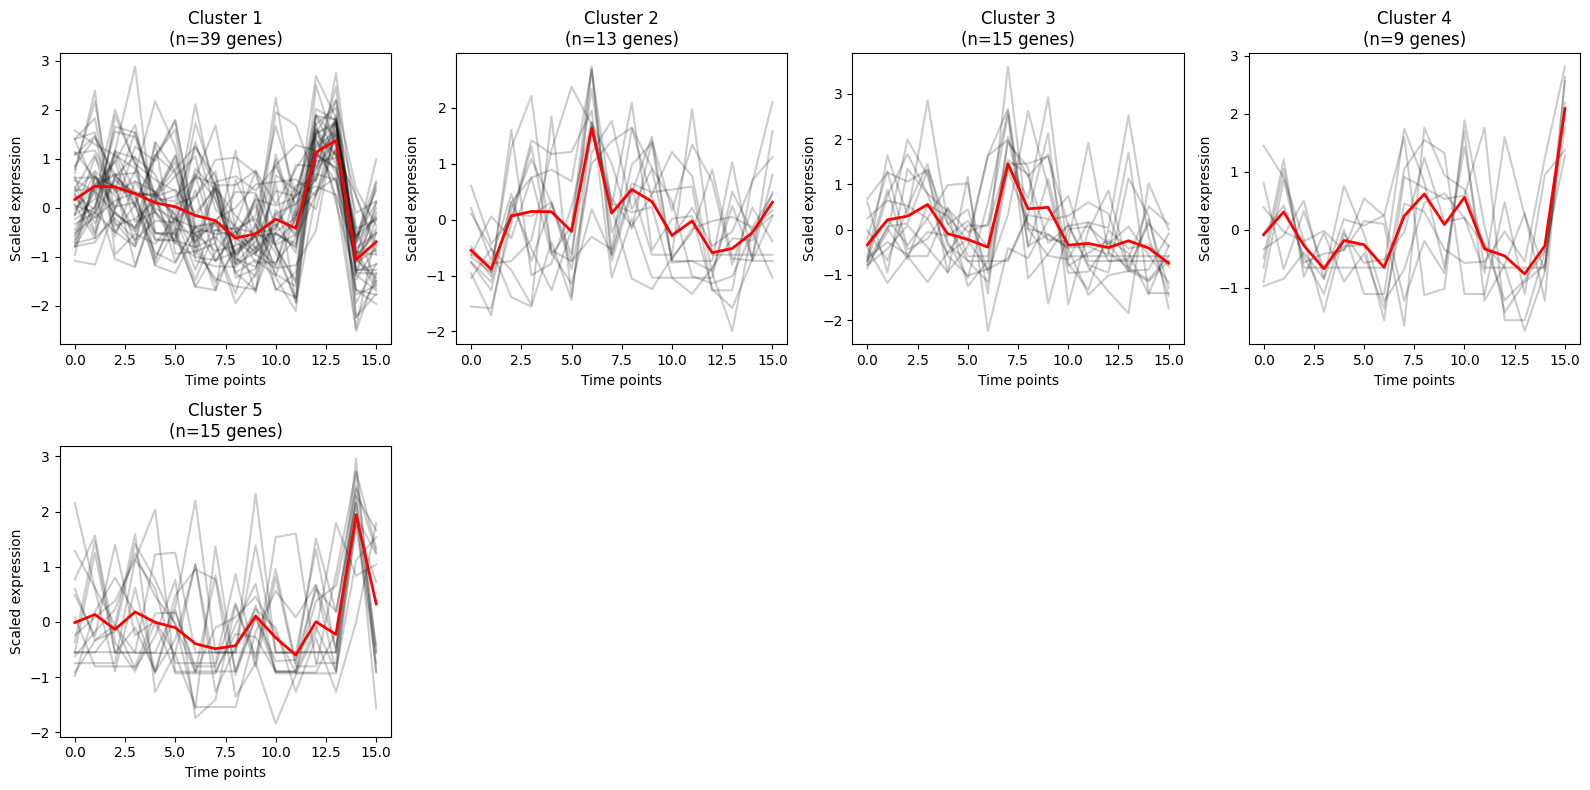

Average silhouette score = 0.2368


In [29]:
import pandas as pd
import numpy as np
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import math

# -----------------------
# 1. Load data
# -----------------------
df = pd.read_csv(
    'input_data/Cluster_F10/Genexpression/cluster_gene_expression_based_on_r5_fpkm_6400_net_m_7_0.01',
    index_col=0, sep='\t'
)
X = df.values  # genes x 16 timepoints

# -----------------------
# 2. Scale each gene (optional but recommended)
# -----------------------
X_scaled = X.reshape(X.shape[0], X.shape[1], 1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_scaled)
X_scaled_2d = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])

# -----------------------
# 3. Compute correlation distance
# -----------------------
corr = np.corrcoef(X_scaled_2d)
dist = 1 - corr  # correlation-based distance

# -----------------------
# 4. Hierarchical clustering
# -----------------------
# linkage expects a condensed distance matrix, so flatten the upper triangle
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist, checks=False)

# Perform hierarchical clustering (average linkage is common)
Z = linkage(condensed_dist, method='average')

# -----------------------
# 5. Plot dendrogram
# -----------------------
plt.figure(figsize=(15, 6))
dendrogram(Z, labels=df.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.95)
plt.title("Hierarchical clustering dendrogram (correlation distance)")
plt.ylabel("Correlation distance")
plt.show()

# -----------------------
# 6. Silhouette analysis for different k
# -----------------------
silhouette_scores = {}
for k in range(2, 16):  # test k from 2 to 15
    cluster_labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(dist, cluster_labels, metric="precomputed")
    silhouette_scores[k] = score
    print(f"Silhouette score for k={k}: {score:.3f}")


# -----------------------
# 6. Assign clusters
# -----------------------
n_clusters = 5 # choose based on dendrogram or desired number of clusters
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# -----------------------
# 7. Plot line profiles per cluster
# -----------------------


# Determine number of rows and columns
cols = 4
rows = math.ceil(n_clusters / cols)

plt.figure(figsize=(cols * 4, rows * 4))  # scale figure size with number of cols/rows

for yi in range(1, n_clusters + 1):
    ax = plt.subplot(rows, cols, yi)
    
    cluster_data = X_scaled_2d[cluster_labels == yi]
    
    # Plot all genes in black
    for xx in cluster_data:
        plt.plot(xx.ravel(), "k-", alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.ravel(), "r-", linewidth=2)
    
    plt.title(f"Cluster {yi}\n(n={cluster_data.shape[0]} genes)")
    plt.xlabel("Time points")
    plt.ylabel("Scaled expression")

plt.tight_layout()
plt.show()

# Silhouette score
silhouette_avg = silhouette_score(dist, cluster_labels, metric="precomputed")
print(f"Average silhouette score = {silhouette_avg:.4f}")

# export cluster assignments together with time series data
cluster_df = df.copy()
cluster_df['cluster'] = cluster_labels
cluster_df.to_csv('hierarchical_clustering_clusters_m7.csv', index=True)